# Final Project: Kalshi Market Making in short-dated SPX Events

Chris Mulligan (12502987), George Lord (12243747), Max Zhalilo (12341701)

# Content

0. Abstract
1. Introduction
2. Data
3. Techniques and Theory Details in the Strategy
4. Implementation of our Strategy
5. Result/Analysis


# 0. Abstract

We use statistical modeling & black-scholes to price Kalshi short-dates SPX events. We simulate an automated market making strategy in these events using a simulator that directly interfaces with our trading modules. We delta hedge SPX exposure by trading the SPY ETF. We test the performance of our strategy over 2 months.

# 1. Introduction

In modern financial markets, algorithmic trading and automated market making have become central components of liquidity provision and price discovery. Electronic Market Makers such as Jump & Virtu have begun to expand into prediction markets such as Kalshi & Polymarket to profit from their increasing trading volumes. In this project, we develop and test a fully systematic market-making strategy for short-dated S&P 500 (SPX) event contracts listed on Kalshi. These contracts pay a fixed $1 if a specified event occurs—such as the SPX closing above a certain level-and $0 otherwise. As a result, they can be interpreted as binary options on the terminal value of the SPX index.

The core idea of our strategy is grounded in Black-Scholes derivative pricing theory. A binary call option has a value equal to the discounted risk-neutral probability that the underlying asset finishes above a given strike at expiration. For contracts with 0–1 days to expiration, discounting effects are negligible (??? LETS THINK ABOUT THIS ???), so the contract price closely approximates the market-implied probability of the event occurring. By modeling the terminal distribution of SPX under a log-normal assumption consistent with the Black–Scholes framework, we can estimate these probabilities analytically using closed-form expressions. Specifically, we compute the cumulative distribution function (CDF) implied by current SPX levels, time to expiration, and volatility, with volatility proxied by the VIX index.

Once fair values for binary calls and puts are obtained, we replicate the payoff structures of Kalshi’s SPX “above” and “range” contracts using combinations of these binaries. This replication framework provides a theoretical benchmark price for each listed contract. The strategy then centers its market-making quotes around these fair values and dynamically adjusts bid–ask spreads as a function of market volatility, time to expiration, tick size constraints, exchange fees, and current inventory. In higher-volatility or low-liquidity environments, spreads are widened to compensate for increased uncertainty and adverse selection risk.

Because the fair value of each contract is sensitive to movements in the underlying SPX index, holding inventory in Kalshi contracts introduces directional exposure. To manage this risk, we compute the delta of each replicated binary position with respect to SPX and aggregate the book’s total delta exposure. We then hedge this exposure using the SPY ETF, which closely tracks SPX movements. This delta-hedging process isolates the strategy’s profit and loss primarily to bid–ask spread capture and pricing inefficiencies rather than outright market direction.

We test our strategy in a simulator that mimics Kalshi exchange capability. We've built out our strategy using pricing, market making, hedging, & position management modules, all of which interact with the simulator using our execution engine module. Our objective is to assess whether theoretically grounded probability estimates, combined with disciplined spread management and delta hedging, can generate consistent risk-adjusted returns in short-dated event markets.

# 2. Data

## 1.1: Imports and paths

We are going to load our parquet files and compute the shared state as the latest first-date across the three raw parquets. Therefore, all datasets will overlap in day one.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
DATA_DIR = Path("Data")

_mins = {
    "spx": pl.scan_parquet(DATA_DIR / "spx_1s_2026-01-01_to_2026-02-26.parquet")
               .select(pl.col("time").min()).collect().item(),
    "vix": pl.scan_parquet(DATA_DIR / "vix_1s_2026-01-01_to_2026-02-26.parquet")
               .select(pl.col("time").min()).collect().item(),
    "spy": pl.scan_parquet(DATA_DIR / "spy_ohlcv_1s_rth.parquet")
               .select(pl.col("ts").min()).collect().item(),
}

START = str(max(_mins.values()).date())
END   = "2026-02-27"

for k, v in _mins.items():
    print(f"  {k} first timestamp : {v}")
print(f"\nSTART = {START}  (max of the three minimums)")
print(f"END   = {END}")

def rth_filter(col: str = "ts") -> pl.Expr:
    """Keep only regular trading hours: 9:30:00 – 16:00:00 ET.

    - after_open  : after 9:30 (exclusive of 9:00–9:29)
    - before_close: before 16:00, plus the 16:00:00 closing print only
      (hour <= 16 alone would let 16:01–16:59 through)
    - Avoids multiplying dt.hour() by 60 — dt.hour() is Int8 in this
      polars version, so values >= 128 would silently overflow.
    """
    hour   = pl.col(col).dt.hour()
    minute = pl.col(col).dt.minute()
    after_open   = (hour > 9) | ((hour == 9) & (minute >= 30))
    before_close = (hour < 16) | ((hour == 16) & (minute == 0))
    return after_open & before_close

  spx first timestamp : 2026-01-02 09:30:01-05:00
  vix first timestamp : 2026-01-02 03:15:01-05:00
  spy first timestamp : 2024-01-02 09:30:00-05:00

START = 2026-01-02  (max of the three minimums)
END   = 2026-02-27


## 1.2: SPX Series

We are taking the raw file `spx_1s_2026-01-01_to_2026-02-26.parquet` and cleaning. It began with shape (994,773, 2) with columns
* `price`
* `time`

We solved the following issues
* `time` renamed to `ts` for consistency across all datasets
* `price` renamed to `spx` so the column is self-describing after joins
* ~38 minutes of post-market data trimmed (raw data runs to 16:38:48)
* `date` string column added for easy join with Kalshi trade tables

In [ ]:
spx = (
    pl.read_parquet(DATA_DIR / "spx_1s_2026-01-01_to_2026-02-26.parquet")
    .rename({"time": "ts", "price": "spx"})
    .filter(rth_filter("ts"))
    .with_columns(
        pl.col("ts").dt.date().cast(pl.String).alias("date")
    )
    .select(["date", "ts", "spx"])
    .sort("ts")
)

assert spx.null_count().sum_horizontal().item() == 0, "Unexpected nulls in SPX"
assert spx["ts"].dt.hour().min() >= 9,  "SPX: timestamp before 9am"
assert spx["ts"].dt.hour().max() <= 16, "SPX: timestamp after 4pm"

print(f"SPX rows      : {spx.height:,}")
print(f"Date range    : {spx['ts'].min()}  ->  {spx['ts'].max()}")
print(f"Price range   : {spx['spx'].min():.2f}  -  {spx['spx'].max():.2f}")
print(f"Trading days  : {spx['date'].n_unique()}")
spx.head()

SPX rows      : 891,442
Date range    : 2026-01-02 09:30:01-05:00  ->  2026-02-26 16:00:59-05:00
Price range   : 6775.50  -  7002.28
Trading days  : 38


date,ts,spx
str,"datetime[μs, America/New_York]",f64
"""2026-01-02""",2026-01-02 09:30:01 EST,6878.11
"""2026-01-02""",2026-01-02 09:30:02 EST,6880.86
"""2026-01-02""",2026-01-02 09:30:03 EST,6881.53
"""2026-01-02""",2026-01-02 09:30:04 EST,6882.16
"""2026-01-02""",2026-01-02 09:30:05 EST,6881.47


## 1.3: VIX Series

We are taking the raw file `vix_1s_2026-01-01_to_2026-02-26.parquet` and cleaning. It began with shape (1,837,840, 2) with columns
* Price
* Time

We solved the following issues
* `time` renamed to `ts`, `price` renamed to `vix`
* Extended hours stripped: raw data starts at 03:15 AM (VIX calculates continuously from SPX options; we keep only RTH to align with SPX/SPY)
* `date` string column added

In [ ]:
vix = (
    pl.read_parquet(DATA_DIR / "vix_1s_2026-01-01_to_2026-02-26.parquet")
    .rename({"time": "ts", "price": "vix"})
    .filter(rth_filter("ts"))
    .with_columns(
        pl.col("ts").dt.date().cast(pl.String).alias("date")
    )
    .select(["date", "ts", "vix"])
    .sort("ts")
)

assert vix.null_count().sum_horizontal().item() == 0, "Unexpected nulls in VIX"
assert vix["ts"].dt.hour().min() >= 9,  "VIX: timestamp before 9am"
assert vix["ts"].dt.hour().max() <= 16, "VIX: timestamp after 4pm"

print(f"VIX rows      : {vix.height:,}")
print(f"Date range    : {vix['ts'].min()}  ->  {vix['ts'].max()}")
print(f"VIX range     : {vix['vix'].min():.2f}  -  {vix['vix'].max():.2f}")
print(f"Trading days  : {vix['date'].n_unique()}")
vix.head()

VIX rows      : 905,884
Date range    : 2026-01-02 09:30:00-05:00  ->  2026-02-26 16:00:59-05:00
VIX range     : 14.43  -  23.10
Trading days  : 40


date,ts,vix
str,"datetime[μs, America/New_York]",f64
"""2026-01-02""",2026-01-02 09:30:00 EST,14.74
"""2026-01-02""",2026-01-02 09:30:01 EST,14.74
"""2026-01-02""",2026-01-02 09:30:02 EST,14.74
"""2026-01-02""",2026-01-02 09:30:03 EST,14.74
"""2026-01-02""",2026-01-02 09:30:04 EST,14.74


## 1.4: SPY Series

We are taking the raw file `spy_ohlcv_1s_rth.parquet` and cleaning. It began with shape (9,119,728, 7) with columns
* ts
* open
* high
* low
* close
* volume
* symbol

We solved the following issues
* Timestamp downcast from nanoseconds -> microseconds (matches SPX/VIX and the Kalshi trade tables; ns precision is meaningless for 1s bars)
* `symbol` column dropped (always `SPY`, wastes memory at 9M rows)
* Date range trimmed to 2026 to match SPX/VIX window (raw file covers 2024-01-02 to 2026-02-25)
* `date` string column added

In [ ]:
spy = (
    pl.read_parquet(DATA_DIR / "spy_ohlcv_1s_rth.parquet")
    .drop("symbol")
    .with_columns(
        pl.col("ts").dt.cast_time_unit("us"),
        pl.col("ts").dt.date().cast(pl.String).alias("date"),
    )
    .filter(pl.col("date").is_between(pl.lit(START), pl.lit(END)))
    .select(["date", "ts", "open", "high", "low", "close", "volume"])
    .sort("ts")
)

assert spy.null_count().sum_horizontal().item() == 0, "Unexpected nulls in SPY"
assert spy["volume"].min() > 0, "SPY: zero-volume bar found"

print(f"SPY rows      : {spy.height:,}")
print(f"Date range    : {spy['ts'].min()}  ->  {spy['ts'].max()}")
print(f"Close range   : {spy['close'].min():.2f}  -  {spy['close'].max():.2f}")
print(f"Trading days  : {spy['date'].n_unique()}")
spy.head()

SPY rows      : 767,574
Date range    : 2026-01-02 09:30:00-05:00  ->  2026-02-25 15:59:59-05:00
Close range   : 675.79  -  697.82
Trading days  : 37


date,ts,open,high,low,close,volume
str,"datetime[μs, America/New_York]",f64,f64,f64,f64,i64
"""2026-01-02""",2026-01-02 09:30:00 EST,685.71,685.73,685.49,685.52,30504
"""2026-01-02""",2026-01-02 09:30:01 EST,685.52,685.57,685.49,685.5,13034
"""2026-01-02""",2026-01-02 09:30:02 EST,685.5,685.58,685.48,685.48,40579
"""2026-01-02""",2026-01-02 09:30:03 EST,685.48,685.48,685.38,685.44,11990
"""2026-01-02""",2026-01-02 09:30:04 EST,685.45,685.48,685.43,685.44,12449


## 1.5: Save Cleaned Files

We are writing one parquet per asset into Data/ alongside the raw files. We will load these `_clean` files everywhere else in the project

In [ ]:
for name, df in [("spx", spx), ("vix", vix), ("spy", spy)]:
    path = DATA_DIR / f"{name}_clean.parquet"
    df.write_parquet(path, compression="zstd", compression_level=3)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved {path.name:30s}  {df.height:>9,} rows  {size_mb:.1f} MB")

Saved spx_clean.parquet                 891,442 rows  4.4 MB
Saved vix_clean.parquet                 905,884 rows  2.7 MB
Saved spy_clean.parquet                 767,574 rows  7.4 MB


## 1.6: KXINX Contracts

We take the folder of parquetes in the KXINX contracts, combine, and clean. The KXINX contract is Kalshi's daily SPX close RANGE (bracket) market. Each contract pays $1 if SPX closes within a specific 25-point bracket. There are 208 files totally about 14k trades. 

The ticker can be interpreted as follows:
* Format: KXINX - {YYMONDD} H1600 - B{midpoint}
* Example: KXINX-26FEB02H1600-B6912
* Series: KXINX  (SPX close range)
* Expiry: Feb 2, 2026 at 16:00 ET  (same-day settlement at market close)
* B6912: bracket midpoint label; floor = (6912 // 25) * 25 = 6900 → contract pays if SPX closes in [6900, 6924.9999]

For each day, 6 contracts were selected (3 above + 3 below the SPX close):
* side_of_close = "above"  → bracket is entirely above the actual SPX close
* side_of_close = "below"  → bracket is entirely below the actual SPX close

We solved the following issues: 
* Consolidate all 208 per-ticker parquet files into one DataFrame
* Convert ts from UTC → America/New_York (consistent with SPX/VIX/SPY)
* Parse bracket floor/cap from ticker suffix  (-B{midpoint})
* Derive contract_desc: human-readable label for each unique contract
* Validate: price ∈ [0, 1], quantity > 0, no nulls in key columns

In [ ]:
kxinx = (
    pl.read_parquet("Data-Exploration/parquet_exports/1_2/*.parquet")
    .with_columns(
        # Convert trade timestamps from UTC to Eastern time
        pl.col("ts").dt.convert_time_zone("America/New_York"),

        # Recover bracket floor from the ticker suffix "-B{midpoint}":
        #   midpoint (e.g. 6912) is the centre of a 25-pt bracket.
        #   floor = (midpoint // 25) * 25   →   6912 // 25 * 25 = 6900
        (
            pl.col("ticker").str.extract(r"-B(\d+)$", 1)
              .cast(pl.Int32) // 25 * 25
        ).cast(pl.Float64).alias("bracket_floor"),
    )
    .with_columns(
        # cap = floor + 25  (Kalshi stores it as floor + 24.9999, same thing)
        (pl.col("bracket_floor") + 25.0).alias("bracket_cap"),

        # Human-readable contract label
        pl.concat_str([
            pl.lit("KXINX: SPX in ["),
            pl.col("bracket_floor").cast(pl.String),
            pl.lit(", "),
            (pl.col("bracket_floor") + 25.0).cast(pl.String),
            pl.lit(")  exp "),
            pl.col("date"),
        ]).alias("contract_desc"),
    )
    .select([
        "date", "ticker", "contract_desc", "bracket_floor", "bracket_cap",
        "side_of_close", "ts", "price", "quantity",
        "direction", "liquidity_event",
    ])
    .sort(["date", "ticker", "ts"])
)

# Validate
assert kxinx.filter((pl.col("price") < 0) | (pl.col("price") > 1)).height == 0, \
    "KXINX: price outside [0, 1]"
assert kxinx.filter(pl.col("quantity") <= 0).height == 0, \
    "KXINX: non-positive quantity"
assert kxinx.select(["date", "ticker", "ts", "price", "quantity"]) \
    .null_count().sum_horizontal().item() == 0, "KXINX: unexpected nulls"

print(f"KXINX rows          : {kxinx.height:,}")
print(f"Unique contracts    : {kxinx['ticker'].n_unique()}")
print(f"Trading days        : {kxinx['date'].n_unique()}")
print(f"Bracket floor range : {kxinx['bracket_floor'].min():.0f}  –  {kxinx['bracket_floor'].max():.0f}")
print(f"Price range         : {kxinx['price'].min():.2f}  –  {kxinx['price'].max():.2f}")
print(f"\nSample contract descriptions:")
print(kxinx.select(["ticker", "contract_desc", "side_of_close"]).unique(subset=["ticker"]).sort("ticker").head(6))
kxinx.head()


KXINX rows          : 13,617
Unique contracts    : 208
Trading days        : 38
Bracket floor range : 6725  –  7050
Price range         : 0.01  –  0.99

Sample contract descriptions:
shape: (6, 3)
┌──────────────────────────┬─────────────────────────────────┬───────────────┐
│ ticker                   ┆ contract_desc                   ┆ side_of_close │
│ ---                      ┆ ---                             ┆ ---           │
│ str                      ┆ str                             ┆ str           │
╞══════════════════════════╪═════════════════════════════════╪═══════════════╡
│ KXINX-26FEB02H1600-B6912 ┆ KXINX: SPX in [6900.0, 6925.0)… ┆ below         │
│ KXINX-26FEB02H1600-B6937 ┆ KXINX: SPX in [6925.0, 6950.0)… ┆ below         │
│ KXINX-26FEB02H1600-B6962 ┆ KXINX: SPX in [6950.0, 6975.0)… ┆ below         │
│ KXINX-26FEB02H1600-B7012 ┆ KXINX: SPX in [7000.0, 7025.0)… ┆ above         │
│ KXINX-26FEB03H1600-B6837 ┆ KXINX: SPX in [6825.0, 6850.0)… ┆ below         │
│ KXINX-26FEB

date,ticker,contract_desc,bracket_floor,bracket_cap,side_of_close,ts,price,quantity,direction,liquidity_event
str,str,str,f64,f64,str,"datetime[μs, America/New_York]",f64,f64,str,str
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 19:27:55.835333 EST,0.41,15.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 21:46:31.683290 EST,0.41,23.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 22:34:01.204800 EST,0.06,4.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-01 23:14:32.476601 EST,0.06,46.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINX-26JAN02H1600-B6787""","""KXINX: SPX in [6775.0, 6800.0)…",6775.0,6800.0,"""below""",2026-01-02 00:39:11.429760 EST,0.06,50.0,"""no_taker""","""hit_bid"""


## 1.7: KXINXU Contracts

We take the folder of parquetes in the KXINXU contracts, combine, and clean. The KXINXU contract is Kalshi's daily SPX close DIRECTIONAL (unbounded-up) market. Each contract pays $1 if SPX closes ABOVE a fixed threshold on expiry day. These are one-sides - no upper cap. There are 215 files totally about 43k trades. 

The ticker can be interpreted as follows:
* Format: KXINXU - {YYMONDD} H1600 - T{threshold}
* Example: KXINXU-26JAN02H1600-T6799.9999
* Series: KXINXU  (SPX close above threshold)
* Expiry: Jan 2, 2026 at 16:00 ET  (same-day settlement at market close)
* Threshold: 6799.9999  → contract pays if SPX closes above 6799.9999

For each day the same 3-above / 3-below selection was used as in 1.2:
* side_of_close = "above"  → threshold is above that day's actual SPX close
* side_of_close = "below"  → threshold is below that day's actual SPX close

We solved the following issues: 
* Consolidate all 215 per-ticker parquet files into one DataFrame
* Convert ts from UTC → America/New_York (consistent with SPX/VIX/SPY)
* Parse threshold from ticker suffix  (-T{threshold})
* Derive contract_desc: human-readable label for each unique contract
* Validate: price ∈ [0, 1], quantity > 0, no nulls in key columns

In [ ]:
kxinxu = (
    pl.read_parquet("Data-Exploration/parquet_exports/1_4/*.parquet")
    .with_columns(
        # Convert trade timestamps from UTC to Eastern time
        pl.col("ts").dt.convert_time_zone("America/New_York"),

        # Extract the threshold value from the ticker suffix "-T{threshold}"
        # Example: KXINXU-26JAN02H1600-T6799.9999  →  threshold = 6799.9999
        pl.col("ticker")
          .str.extract(r"-T([\d.]+)$", 1)
          .cast(pl.Float64)
          .alias("threshold"),
    )
    .with_columns(
        # Human-readable contract label
        pl.concat_str([
            pl.lit("KXINXU: SPX > "),
            pl.col("threshold").cast(pl.String),
            pl.lit("  exp "),
            pl.col("date"),
        ]).alias("contract_desc")
    )
    .select([
        "date", "ticker", "contract_desc", "threshold",
        "side_of_close", "ts", "price", "quantity",
        "direction", "liquidity_event",
    ])
    .sort(["date", "ticker", "ts"])
)

# Validate
assert kxinxu.filter((pl.col("price") < 0) | (pl.col("price") > 1)).height == 0, \
    "KXINXU: price outside [0, 1]"
assert kxinxu.filter(pl.col("quantity") <= 0).height == 0, \
    "KXINXU: non-positive quantity"
assert kxinxu.select(["date", "ticker", "ts", "price", "quantity"]) \
    .null_count().sum_horizontal().item() == 0, "KXINXU: unexpected nulls"

print(f"KXINXU rows         : {kxinxu.height:,}")
print(f"Unique contracts    : {kxinxu['ticker'].n_unique()}")
print(f"Trading days        : {kxinxu['date'].n_unique()}")
print(f"Threshold range     : {kxinxu['threshold'].min():.2f}  –  {kxinxu['threshold'].max():.2f}")
print(f"Price range         : {kxinxu['price'].min():.2f}  –  {kxinxu['price'].max():.2f}")
print(f"\nSample contract descriptions:")
print(kxinxu.select(["ticker", "contract_desc", "side_of_close"]).unique(subset=["ticker"]).sort("ticker").head(6))
kxinxu.head()


KXINXU rows         : 43,188
Unique contracts    : 215
Trading days        : 37
Threshold range     : 6725.00  –  7050.00
Price range         : 0.01  –  0.99

Sample contract descriptions:
shape: (6, 3)
┌────────────────────────────────┬─────────────────────────────────┬───────────────┐
│ ticker                         ┆ contract_desc                   ┆ side_of_close │
│ ---                            ┆ ---                             ┆ ---           │
│ str                            ┆ str                             ┆ str           │
╞════════════════════════════════╪═════════════════════════════════╪═══════════════╡
│ KXINXU-26FEB02H1600-T6924.9999 ┆ KXINXU: SPX > 6924.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6949.9999 ┆ KXINXU: SPX > 6949.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6974.9999 ┆ KXINXU: SPX > 6974.9999  exp 2… ┆ below         │
│ KXINXU-26FEB02H1600-T6999.9999 ┆ KXINXU: SPX > 6999.9999  exp 2… ┆ above         │
│ KXINXU-26FEB02H1600-T7024.9999

date,ticker,contract_desc,threshold,side_of_close,ts,price,quantity,direction,liquidity_event
str,str,str,f64,str,"datetime[μs, America/New_York]",f64,f64,str,str
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 08:07:01.212740 EST,0.96,30.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 10:27:44.515689 EST,0.87,100.0,"""no_taker""","""hit_bid"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:04:06.759015 EST,0.86,1.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:05:54.618135 EST,0.88,100.0,"""yes_taker""","""lift_offer"""
"""2026-01-02""","""KXINXU-26JAN02H1600-T6799.9999""","""KXINXU: SPX > 6799.9999 exp 2…",6799.9999,"""below""",2026-01-02 11:07:38.803017 EST,0.84,1.0,"""yes_taker""","""lift_offer"""


## 1.8: Save Cleaned Kalshi Files

We write both consolidated Kalshi tables into Data/ so we can use them for the rest of the project

In [ ]:
for name, df in [("kalshi_kxinx_clean", kxinx), ("kalshi_kxinxu_clean", kxinxu)]:
    path = Path("Data") / f"{name}.parquet"
    df.write_parquet(path, compression="zstd", compression_level=3)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved {path.name:35s}  {df.height:>7,} rows  {size_mb:.1f} MB")


Saved kalshi_kxinx_clean.parquet            13,617 rows  0.1 MB
Saved kalshi_kxinxu_clean.parquet           43,188 rows  0.3 MB


# Data Analysis

## 2.1: Load Cleaned Parquets and Compute Daily Aggregates

We derive the daily aggregates for initial analysis, although our strategy will rely on a 1s scale.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("Data")

spx = pl.read_parquet(DATA_DIR / "spx_clean.parquet")
vix = pl.read_parquet(DATA_DIR / "vix_clean.parquet")
spy = pl.read_parquet(DATA_DIR / "spy_clean.parquet")

# --- daily aggregates ---------------------------------------------------

# SPX: first tick = open, last tick = close (forward-filled 1s series)
spx_daily = (
    spx.sort("ts")
    .group_by("date")
    .agg(
        pl.col("spx").first().alias("open"),
        pl.col("spx").last().alias("close"),
        pl.col("spx").max().alias("high"),
        pl.col("spx").min().alias("low"),
    )
    .sort("date")
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).mul(100).alias("ret_pct")
    )
)

# VIX: last tick of the day = closing level
vix_daily = (
    vix.sort("ts")
    .group_by("date")
    .agg(pl.col("vix").last().alias("close"))
    .sort("date")
)

# SPY: first open, last close, session high/low, total volume
spy_daily = (
    spy.sort("ts")
    .group_by("date")
    .agg(
        pl.col("open").first().alias("open"),
        pl.col("close").last().alias("close"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("volume").sum().alias("volume"),
    )
    .sort("date")
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).mul(100).alias("ret_pct")
    )
)

print(f"SPX daily rows : {spx_daily.height}  |  return mean: {spx_daily['ret_pct'].drop_nulls().mean():.3f}%  std: {spx_daily['ret_pct'].drop_nulls().std():.3f}%")
print(f"VIX daily rows : {vix_daily.height}  |  avg close: {vix_daily['close'].mean():.2f}")
print(f"SPY daily rows : {spy_daily.height}  |  avg volume: {spy_daily['volume'].mean():,.0f}")


SPX daily rows : 38  |  return mean: 0.023%  std: 0.767%
VIX daily rows : 40  |  avg close: 17.63
SPY daily rows : 37  |  avg volume: 18,916,099


## 2.2: Graph 1: SPX Close Price and VIX Level

We vertically stack panels sharing an x-axis. The inverse relationship between SPX and VIX is the central dynamic in pricing Kalshi binary contracts: rising VIX widens the probable range of SPX outcomes and inflates the price of out-of-money brackets. 

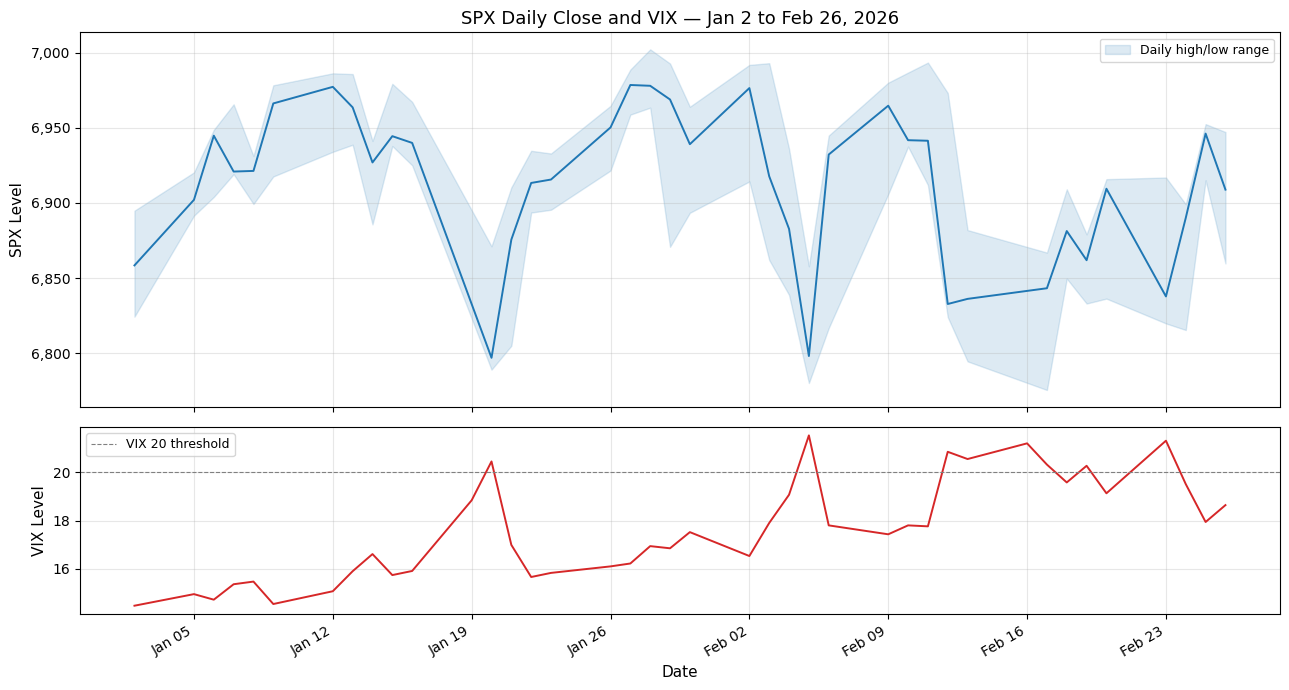

In [ ]:
spx_pd = spx_daily.to_pandas()
vix_pd = vix_daily.to_pandas()
spx_pd["date"] = pd.to_datetime(spx_pd["date"])
vix_pd["date"] = pd.to_datetime(vix_pd["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# --- SPX panel ---
ax1.plot(spx_pd["date"], spx_pd["close"], color="#1f77b4", linewidth=1.4)
ax1.fill_between(spx_pd["date"], spx_pd["low"], spx_pd["high"],
                 alpha=0.15, color="#1f77b4", label="Daily high/low range")
ax1.set_ylabel("SPX Level", fontsize=11)
ax1.set_title("SPX Daily Close and VIX — Jan 2 to Feb 26, 2026", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# --- VIX panel ---
ax2.plot(vix_pd["date"], vix_pd["close"], color="#d62728", linewidth=1.4)
ax2.axhline(20, color="grey", linestyle="--", linewidth=0.8, label="VIX 20 threshold")
ax2.set_ylabel("VIX Level", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


## 2.3: Graph 2: SPX Daily Return Distribution

The distribution of daily SPX returns determines how often the index crosses any given strike level — directly setting the fair value of Kalshi's range and directional contracts. A normal overlay is included to show how much the actual distribution deviates from the Gaussian assumption.

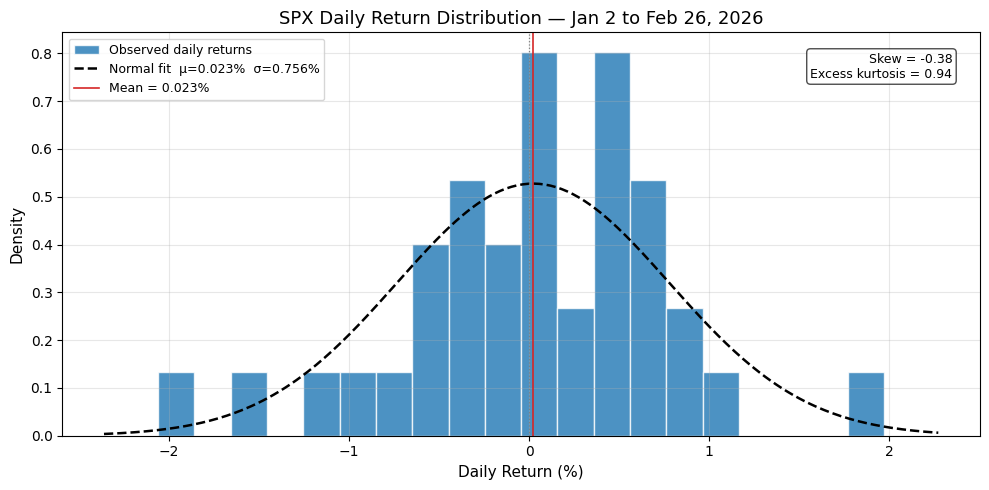

In [ ]:
returns = spx_daily["ret_pct"].drop_nulls().to_numpy()
mu, sigma = returns.mean(), returns.std()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(returns, bins=20, color="#1f77b4", edgecolor="white",
        alpha=0.8, density=True, label="Observed daily returns")

# Normal distribution overlay
x = np.linspace(returns.min() - 0.3, returns.max() + 0.3, 300)
ax.plot(x, (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2),
        color="black", linewidth=1.8, linestyle="--", label=f"Normal fit  μ={mu:.3f}%  σ={sigma:.3f}%")

ax.axvline(0, color="grey", linewidth=0.9, linestyle=":")
ax.axvline(mu, color="#d62728", linewidth=1.2, linestyle="-",
           label=f"Mean = {mu:.3f}%")

ax.set_xlabel("Daily Return (%)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("SPX Daily Return Distribution — Jan 2 to Feb 26, 2026", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Annotate skew and kurtosis
from scipy import stats as sp_stats
sk = sp_stats.skew(returns)
ku = sp_stats.kurtosis(returns)
ax.text(0.97, 0.95, f"Skew = {sk:.2f}\nExcess kurtosis = {ku:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()


## 2.4: Graph 3: SPX Daily Return vs Opening VIX Level

Each dot is one trading day. Higher VIX at the open signals wider expected moves — Kalshi contracts priced before 9:30 must anticipate this. The scatter shows whether realised SPX swings actually widen with VIX, and whether VIX predicts the direction of the move.

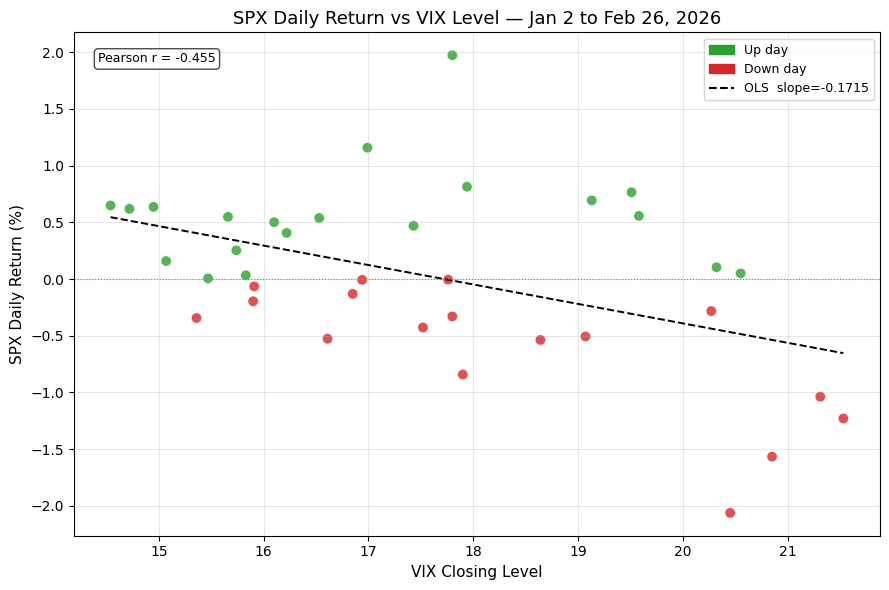

In [ ]:
joined = (
    spx_daily.select(["date", "ret_pct"])
    .join(vix_daily.rename({"close": "vix_close"}), on="date", how="inner")
    .drop_nulls()
    .to_pandas()
)

colors = ["#2ca02c" if r > 0 else "#d62728" for r in joined["ret_pct"]]

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(joined["vix_close"], joined["ret_pct"],
           c=colors, s=55, alpha=0.8, edgecolors="white", linewidths=0.4)

# OLS regression line
m, b = np.polyfit(joined["vix_close"], joined["ret_pct"], 1)
xr = np.linspace(joined["vix_close"].min(), joined["vix_close"].max(), 100)
ax.plot(xr, m * xr + b, color="black", linewidth=1.4, linestyle="--",
        label=f"OLS  slope={m:.4f}  intercept={b:.3f}")

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")

# Dummy patches for legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2ca02c", label="Up day"),
    Patch(color="#d62728", label="Down day"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"OLS  slope={m:.4f}")
], fontsize=9)

ax.set_xlabel("VIX Closing Level", fontsize=11)
ax.set_ylabel("SPX Daily Return (%)", fontsize=11)
ax.set_title("SPX Daily Return vs VIX Level — Jan 2 to Feb 26, 2026", fontsize=13)
ax.grid(alpha=0.3)

corr = joined["vix_close"].corr(joined["ret_pct"])
ax.text(0.03, 0.96, f"Pearson r = {corr:.3f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()


## 2.5: Graph 4: Average Intraday SPX Price Path (Normalized to Open)

For each trading day, every second's price is expressed as a % deviation from that day's 9:30 open. Averaging across all 38 days reveals a systematic intraday drift pattern. This matters for Kalshi contracts because they settle at the 4 PM close: if the index systematically drifts in a direction during the day, the morning market price of a contract should embed that expected drift.


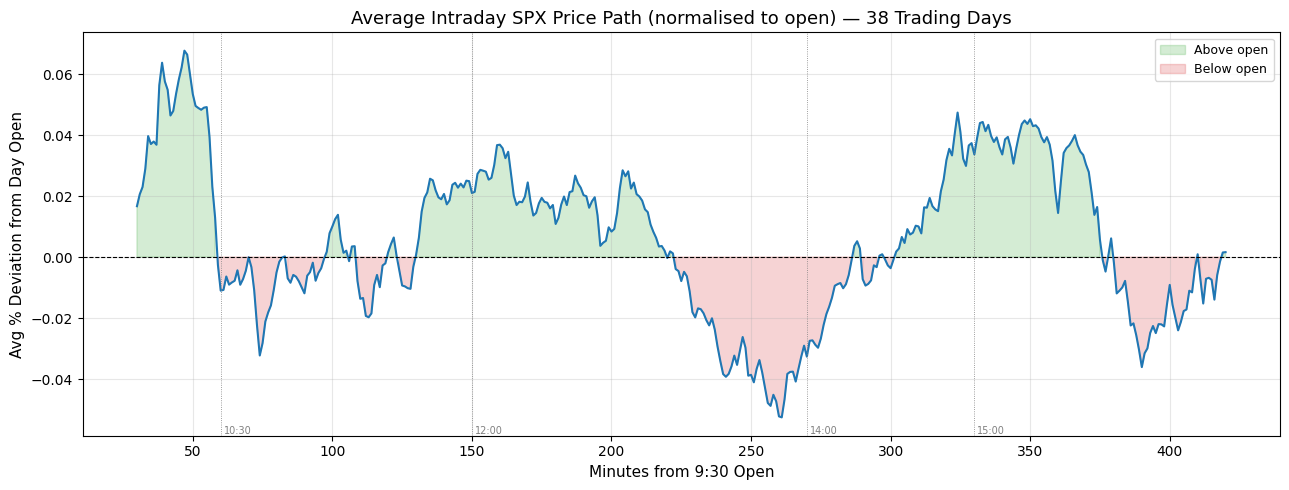

In [ ]:
# Normalise each second's price to that day's 9:30 open
spx_norm = (
    spx.sort("ts")
    .with_columns(
        pl.col("spx").first().over("date").alias("day_open"),
        pl.col("ts").dt.hour().cast(pl.Int16).alias("hour"),
        pl.col("ts").dt.minute().cast(pl.Int16).alias("minute"),
        pl.col("ts").dt.second().cast(pl.Int16).alias("second"),
    )
    .with_columns(
        ((pl.col("spx") / pl.col("day_open") - 1) * 100).alias("norm_pct"),
        (
            (pl.col("hour") - 9) * 3600
            + pl.col("minute") * 60
            + pl.col("second")
        ).alias("sec_from_open"),
    )
)

# Average normalised price by second-from-open, then resample to 1-minute
# buckets for a readable plot
intraday = (
    spx_norm
    .group_by("sec_from_open")
    .agg(pl.col("norm_pct").mean())
    .sort("sec_from_open")
    .with_columns(
        (pl.col("sec_from_open") // 60).alias("min_from_open")
    )
    .group_by("min_from_open")
    .agg(pl.col("norm_pct").mean())
    .sort("min_from_open")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(intraday["min_from_open"], intraday["norm_pct"],
        color="#1f77b4", linewidth=1.5)
ax.fill_between(intraday["min_from_open"], intraday["norm_pct"], 0,
                where=(intraday["norm_pct"] >= 0),
                alpha=0.2, color="#2ca02c", label="Above open")
ax.fill_between(intraday["min_from_open"], intraday["norm_pct"], 0,
                where=(intraday["norm_pct"] < 0),
                alpha=0.2, color="#d62728", label="Below open")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Label key times
for label, minute in [("10:30", 60), ("12:00", 150), ("14:00", 270), ("15:00", 330)]:
    ax.axvline(minute, color="grey", linewidth=0.6, linestyle=":")
    ax.text(minute + 1, ax.get_ylim()[0], label, fontsize=7, color="grey", va="bottom")

ax.set_xlabel("Minutes from 9:30 Open", fontsize=11)
ax.set_ylabel("Avg % Deviation from Day Open", fontsize=11)
ax.set_title("Average Intraday SPX Price Path (normalised to open) — 38 Trading Days", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2.6: Graph 5: SPY Daily Close Price and Total Session Volume

SPY is the most liquid equity ETF and tracks SPX at ~1/10 scale. Volume is unavailable for the SPX index itself, so SPY volume serves as the best proxy for S&P 500 market activity. Heavy-volume days tend to produce larger SPX moves, widening the distribution of outcomes that Kalshi bracket contracts must price.

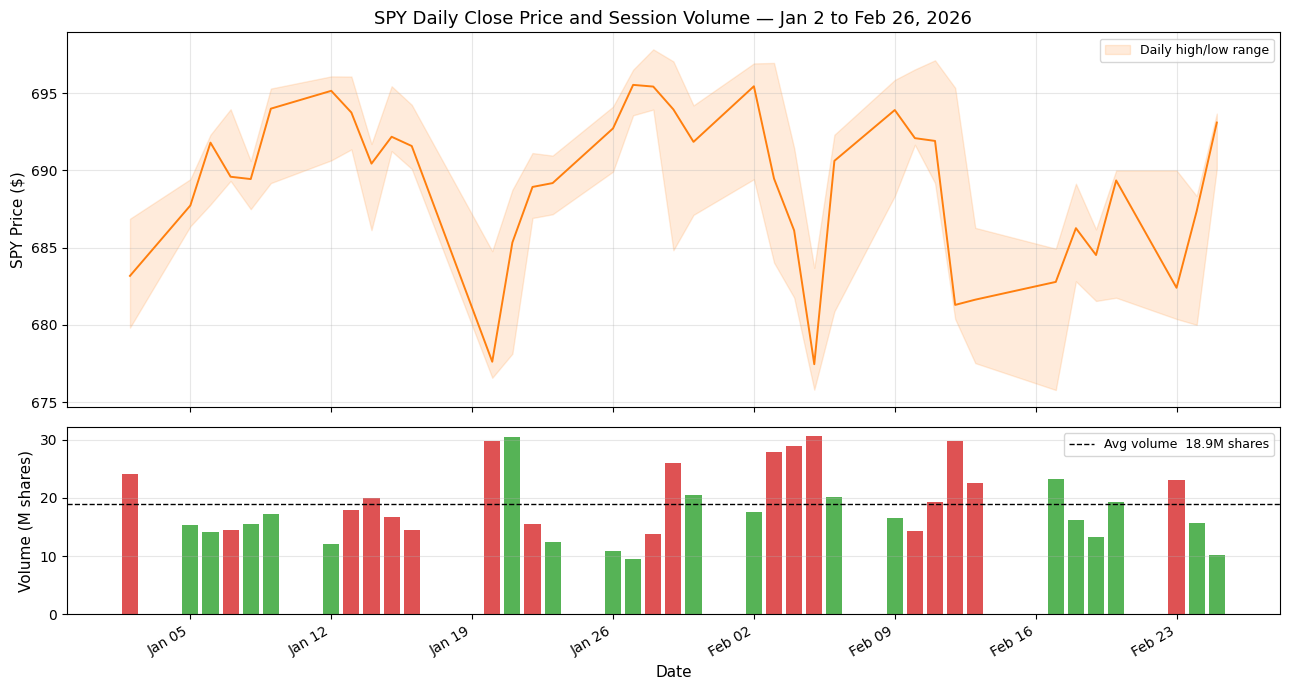

In [ ]:
spy_pd = spy_daily.to_pandas()
spy_pd["date"] = pd.to_datetime(spy_pd["date"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# --- SPY price panel ---
ax1.plot(spy_pd["date"], spy_pd["close"], color="#ff7f0e", linewidth=1.4)
ax1.fill_between(spy_pd["date"], spy_pd["low"], spy_pd["high"],
                 alpha=0.15, color="#ff7f0e", label="Daily high/low range")
ax1.set_ylabel("SPY Price ($)", fontsize=11)
ax1.set_title("SPY Daily Close Price and Session Volume — Jan 2 to Feb 26, 2026", fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Colour bars by up/down day
bar_colors = ["#2ca02c" if c >= o else "#d62728"
              for c, o in zip(spy_pd["close"], spy_pd["open"])]

# --- Volume panel ---
ax2.bar(spy_pd["date"], spy_pd["volume"] / 1e6, color=bar_colors,
        alpha=0.8, width=0.8)
avg_vol = spy_pd["volume"].mean() / 1e6
ax2.axhline(avg_vol, color="black", linewidth=1.0, linestyle="--",
            label=f"Avg volume  {avg_vol:.1f}M shares")
ax2.set_ylabel("Volume (M shares)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


## 2.7: Graph 6: SPY Average Intraday Volume Profile

The classic U-shaped intraday volume curve (heavy at open and close, thin at midday). This is directly relevant to the project: Kalshi contracts settle at the 4 PM SPX close, a period of very high SPY volume. High end-of-day liquidity means SPX prices are harder to manipulate near settlement, lending credibility to the contracts' settlement prices.

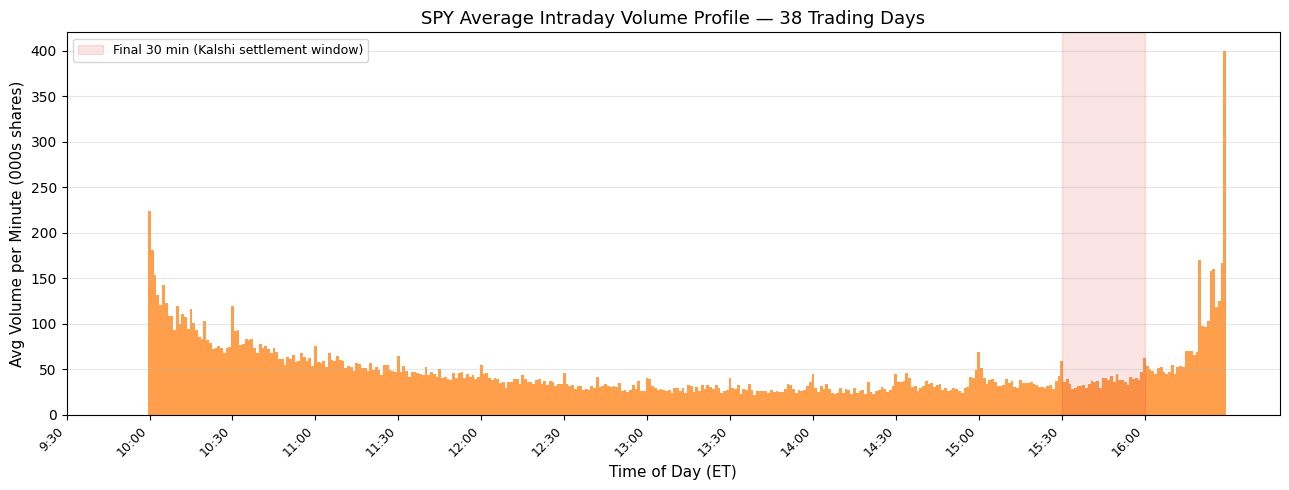

In [ ]:
spy_intraday_vol = (
    spy
    .with_columns(
        pl.col("ts").dt.hour().cast(pl.Int16).alias("hour"),
        pl.col("ts").dt.minute().cast(pl.Int16).alias("minute"),
    )
    .with_columns(
        (
            (pl.col("hour") - 9) * 60 + pl.col("minute")
        ).alias("min_from_open")
    )
    .group_by(["date", "min_from_open"])
    .agg(pl.col("volume").sum().alias("volume"))
    .group_by("min_from_open")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("min_from_open")
    .to_pandas()
)

# x-axis labels: convert minute offset back to clock time
def min_to_label(m):
    total = 9 * 60 + 30 + m
    return f"{total // 60}:{total % 60:02d}"

tick_positions = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390]
tick_labels = [min_to_label(m) for m in tick_positions]

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(spy_intraday_vol["min_from_open"],
       spy_intraday_vol["avg_volume"] / 1e3,
       color="#ff7f0e", alpha=0.75, width=1.0)

# Highlight the last 30 minutes (settlement window for Kalshi contracts)
ax.axvspan(360, 390, alpha=0.12, color="#d62728", label="Final 30 min (Kalshi settlement window)")
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Time of Day (ET)", fontsize=11)
ax.set_ylabel("Avg Volume per Minute (000s shares)", fontsize=11)
ax.set_title("SPY Average Intraday Volume Profile — 38 Trading Days", fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


# Kalshi Contract Analysis

We load the cleaned Kalshi data and compute the daily aggregates as above.

In [ ]:
DATA_DIR = Path("Data")

kxinx  = pl.read_parquet(DATA_DIR / "kalshi_kxinx_clean.parquet")
kxinxu = pl.read_parquet(DATA_DIR / "kalshi_kxinxu_clean.parquet")

# SPX daily close — needed to compute distance from strike to actual close
spx_close_daily = (
    pl.read_parquet(DATA_DIR / "spx_clean.parquet")
    .sort("ts")
    .group_by("date")
    .agg(pl.col("spx").last().alias("spx_close"))
    .sort("date")
)

# Daily trade counts
kxinx_daily  = kxinx.group_by("date").agg(pl.len().alias("trades")).sort("date")
kxinxu_daily = kxinxu.group_by("date").agg(pl.len().alias("trades")).sort("date")

# Per-contract daily VWAP for KXINX, joined with SPX close
kxinx_vwap = (
    kxinx
    .group_by(["date", "ticker", "bracket_floor", "bracket_cap", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        # Distance = index points between SPX close and the nearest bracket edge
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))   # above: floor is nearest edge
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap")) # below: cap is nearest edge
          .alias("distance_from_close")
    )
    .sort(["date", "ticker"])
)

# Per-contract daily VWAP for KXINXU, joined with SPX close
kxinxu_vwap = (
    kxinxu
    .group_by(["date", "ticker", "threshold", "side_of_close"])
    .agg(
        (pl.col("price") * pl.col("quantity")).sum().alias("pq"),
        pl.col("quantity").sum().alias("total_qty"),
    )
    .with_columns((pl.col("pq") / pl.col("total_qty")).alias("vwap"))
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("threshold") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("threshold"))
          .alias("distance_from_close")
    )
    .sort(["date", "ticker"])
)

print(f"KXINX  — {kxinx.height:,} trades | {kxinx['date'].n_unique()} days | {kxinx['ticker'].n_unique()} contracts")
print(f"KXINXU — {kxinxu.height:,} trades | {kxinxu['date'].n_unique()} days | {kxinxu['ticker'].n_unique()} contracts")


KXINX  — 13,617 trades | 38 days | 208 contracts
KXINXU — 43,188 trades | 37 days | 215 contracts


## 3.2: Graph 7: Daily Kalshi contract trade volume over the study period

Side-by-side bars for KXINX (range bracket) and KXINXU (directional) show how trading activity evolved day-by-day.  KXINXU typically has more trades because it offers more individual strike levels than the 25-pt bracket grid.

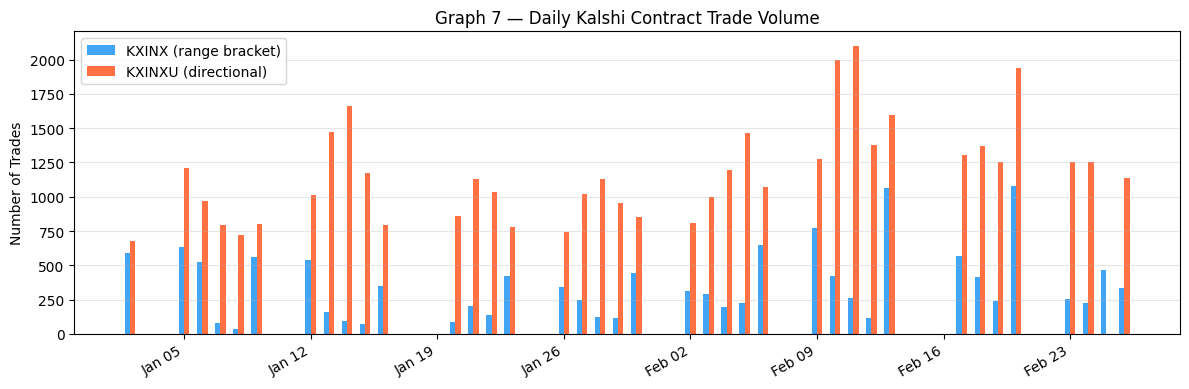

In [ ]:
kxinx_pd  = kxinx_daily.to_pandas()
kxinxu_pd = kxinxu_daily.to_pandas()
kxinx_pd["date"]  = pd.to_datetime(kxinx_pd["date"])
kxinxu_pd["date"] = pd.to_datetime(kxinxu_pd["date"])

fig, ax = plt.subplots(figsize=(12, 4))

width = pd.Timedelta(hours=7)
ax.bar(kxinx_pd["date"]  - width / 2, kxinx_pd["trades"],
       width=width, color="#2196F3", alpha=0.85, label="KXINX (range bracket)")
ax.bar(kxinxu_pd["date"] + width / 2, kxinxu_pd["trades"],
       width=width, color="#FF5722", alpha=0.85, label="KXINXU (directional)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=30)
ax.set_ylabel("Number of Trades")
ax.set_title("Graph 7 — Daily Kalshi Contract Trade Volume")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 3.3 — Graph 8: Yes-price distributions

Prices are stored in dollars (0–1).  Two stories are shown side-by-side:
* Left  (KXINX):  OTM brackets only — prices split by distance from SPX close. Near-ATM brackets command higher prices than deep OTM ones.
* Right (KXINXU): true ITM/OTM split — "above" contracts ITM when spx_close > threshold; "below" contracts ITM when spx_close < threshold.

c:\Users\camul\Downloads\FINM-33150-Final-Project\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


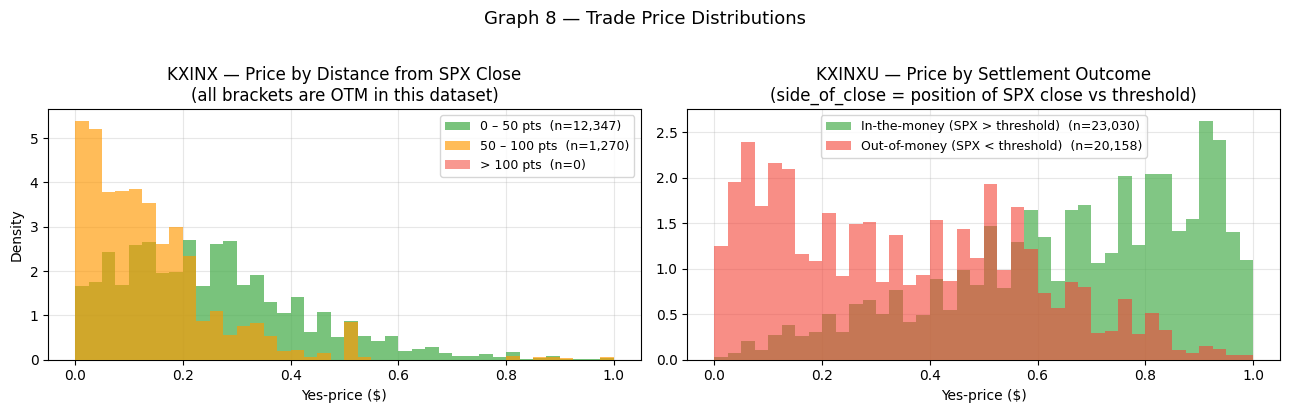

In [40]:
# ── KXINX: per-trade distance bucket ────────────────────────────────────────
kxinx_dist = (
    kxinx
    .join(spx_close_daily, on="date", how="left")
    .with_columns(
        pl.when(pl.col("side_of_close") == "above")
          .then(pl.col("bracket_floor") - pl.col("spx_close"))
          .otherwise(pl.col("spx_close") - pl.col("bracket_cap"))
          .alias("distance")
    )
    .with_columns(
        pl.when(pl.col("distance") <= 50 ).then(pl.lit("0 – 50 pts"))
          .when(pl.col("distance") <= 100).then(pl.lit("50 – 100 pts"))
          .otherwise(pl.lit("> 100 pts"))
          .alias("dist_bucket")
    )
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: KXINX by distance bucket
ax = axes[0]
bucket_styles = {
    "0 – 50 pts":   ("#4CAF50", 0.75),
    "50 – 100 pts": ("#FF9800", 0.65),
    "> 100 pts":    ("#F44336", 0.55),
}
for bucket, (color, alpha) in bucket_styles.items():
    prices = kxinx_dist.filter(pl.col("dist_bucket") == bucket)["price"].to_numpy()
    ax.hist(prices, bins=40, range=(0, 1), color=color, alpha=alpha,
            density=True, label=f"{bucket}  (n={len(prices):,})", zorder=3)
ax.set_xlabel("Yes-price ($)")
ax.set_ylabel("Density")
ax.set_title("KXINX — Price by Distance from SPX Close\n(all brackets are OTM in this dataset)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: KXINXU — side_of_close directly encodes the settlement outcome
ax = axes[1]
# "below" → threshold below final close → YES (above threshold) wins → ITM
# "above" → threshold above final close → YES loses → OTM
for label, soc, color, alpha in [
    ("In-the-money (SPX > threshold)",  "below", "#4CAF50", 0.70),
    ("Out-of-money (SPX < threshold)",  "above", "#F44336", 0.60),
]:
    prices = kxinxu.filter(pl.col("side_of_close") == soc)["price"].to_numpy()
    ax.hist(prices, bins=40, range=(0, 1), color=color, alpha=alpha,
            density=True, label=f"{label}  (n={len(prices):,})", zorder=3)
ax.set_xlabel("Yes-price ($)")
ax.set_title("KXINXU — Price by Settlement Outcome\n(side_of_close = position of SPX close vs threshold)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Graph 8 — Trade Price Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3.4: Graph 9: Intraday KXINX price convergence on the Most Active Trading Day

On each day, all KXINX brackets start the session at some price reflecting the probability the market assigns to SPX closing in that range.  As the session progresses the prices of brackets near the final close should converge toward $1, while all others should converge toward $0.

Note: Note: the winning (ATM) bracket is absent from this data export. We show the 5 available brackets nearest to the SPX close.

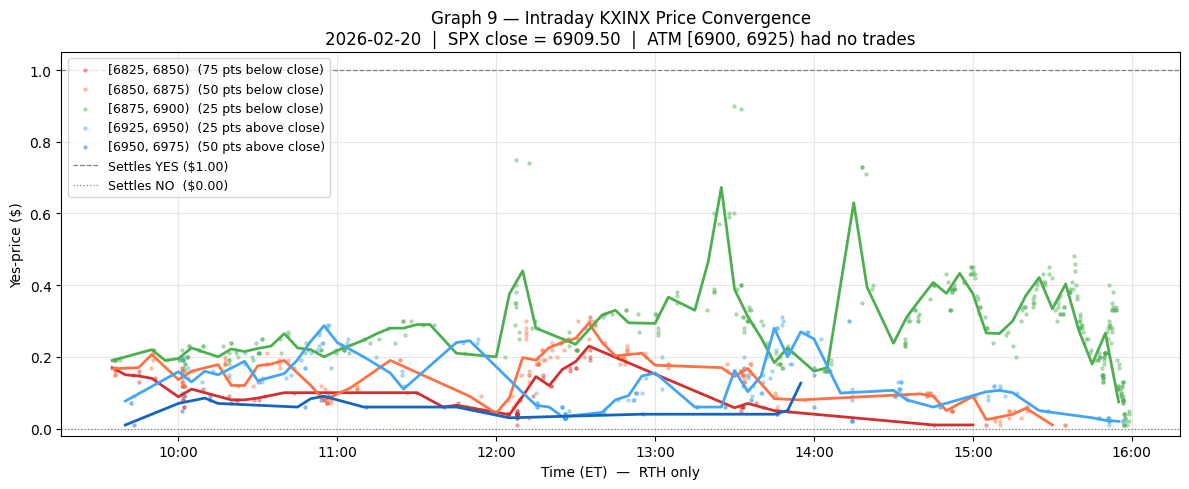

In [41]:
busiest_date = (
    kxinx.group_by("date")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(1)["date"]
    .item()
)
spx_close_val = (
    spx_close_daily
    .filter(pl.col("date") == busiest_date)["spx_close"]
    .item()
)

# ── Filter to RTH on the settlement date ────────────────────────────────────
day_rth = (
    kxinx
    .filter(pl.col("date") == busiest_date)
    .filter(
        (pl.col("ts").dt.hour() > 9) |
        ((pl.col("ts").dt.hour() == 9) & (pl.col("ts").dt.minute() >= 30))
    )
    .filter(pl.col("ts").dt.hour() < 16)
    .select(["ts", "bracket_floor", "bracket_cap", "price"])
    .sort("ts")
)

# ── Pick the 5 available brackets closest to ATM ────────────────────────────
atm_floor    = float((int(spx_close_val) // 25) * 25)
all_floors   = sorted(day_rth["bracket_floor"].unique().to_list())
target_floors = sorted(sorted(all_floors, key=lambda f: abs(f - atm_floor))[:5])

day_pd = (
    day_rth
    .filter(pl.col("bracket_floor").is_in(target_floors))
    .to_pandas()
)
# Strip timezone so matplotlib renders ET wall-clock times (not UTC)
day_pd["ts"] = pd.to_datetime(day_pd["ts"]).dt.tz_localize(None)

# ── Plot ──────────────────────────────────────────────────────────────────────
palette   = ["#d32f2f", "#ff7043", "#4CAF50", "#42a5f5", "#1565c0"]
color_map = {f: c for f, c in zip(target_floors, palette)}

fig, ax = plt.subplots(figsize=(12, 5))

for floor in target_floors:
    sub = day_pd[day_pd["bracket_floor"] == floor].sort_values("ts")
    if sub.empty:
        continue
    c         = color_map[floor]
    dist      = abs(floor - atm_floor)
    direction = "above" if floor >= atm_floor else "below"
    label     = f"[{floor:.0f}, {floor+25:.0f})  ({dist:.0f} pts {direction} close)"

    ax.scatter(sub["ts"], sub["price"], s=5, alpha=0.35, color=c, label=label)
    roll = sub.set_index("ts")["price"].resample("5min").mean().dropna()
    ax.plot(roll.index, roll.values, lw=2, color=c)

ax.axhline(1.0, color="gray", ls="--", lw=0.9, label="Settles YES ($1.00)")
ax.axhline(0.0, color="gray", ls=":",  lw=0.9, label="Settles NO  ($0.00)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.set_xlabel("Time (ET)  —  RTH only")
ax.set_ylabel("Yes-price ($)")
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    f"Graph 9 — Intraday KXINX Price Convergence\n"
    f"{busiest_date}  |  SPX close = {spx_close_val:.2f}  "
    f"|  ATM [{atm_floor:.0f}, {atm_floor+25:.0f}) had no trades"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3.5: Graph 10: Contract VWAP vs Distance from SPX Close (Implied Probability Curve)

For OTM contracts, VWAP should fall as the contract moves further from the money.


KXINX:  all contracts in this dataset are OTM (bracket fully above or below close). distance_from_close = pts from nearest bracket edge to SPX close.

KXINXU: only OTM contracts are shown (side_of_close == "above" means SPX closed ABOVE the threshold → YES (above) contract is OTM; distance = threshold − close). Mixing ITM and OTM would flatten the curve, so we filter to OTM only.

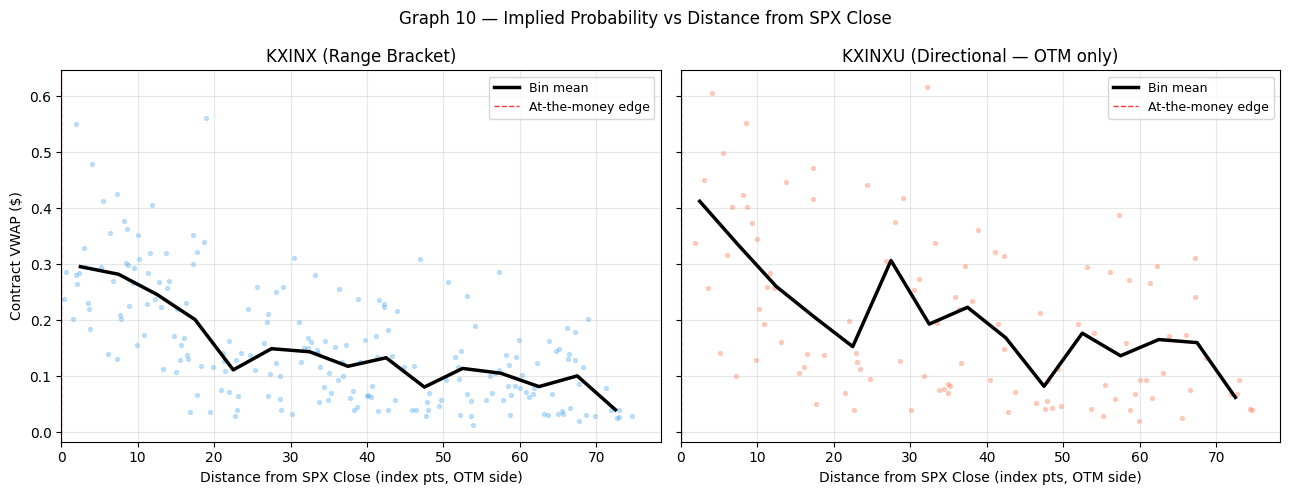

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, vwap_df, title, color, otm_filter in [
    (axes[0], kxinx_vwap,  "KXINX (Range Bracket)", "#2196F3",
     pl.col("distance_from_close").is_not_null() & (pl.col("distance_from_close") >= 0)),
    (axes[1], kxinxu_vwap, "KXINXU (Directional — OTM only)", "#FF5722",
     (pl.col("side_of_close") == "above") &
     pl.col("distance_from_close").is_not_null() &
     (pl.col("distance_from_close") >= 0)),
]:
    df = vwap_df.filter(otm_filter & pl.col("vwap").is_not_null()).to_pandas()

    ax.scatter(df["distance_from_close"], df["vwap"],
               s=8, alpha=0.25, color=color, rasterized=True)

    # Bin-mean overlay in 5-pt buckets
    bin_edges  = np.arange(0, 201, 5)
    bin_labels = np.arange(2.5, 200, 5)
    df["dist_bin"] = pd.cut(df["distance_from_close"], bins=bin_edges, labels=bin_labels)
    binned = (
        df.groupby("dist_bin", observed=True)["vwap"]
        .mean().reset_index()
        .assign(dist_bin=lambda d: d["dist_bin"].astype(float))
        .dropna().sort_values("dist_bin")
    )
    ax.plot(binned["dist_bin"], binned["vwap"],
            color="black", lw=2.5, label="Bin mean")

    ax.axvline(0, color="red", ls="--", lw=1, alpha=0.8, label="At-the-money edge")
    ax.set_xlabel("Distance from SPX Close (index pts, OTM side)")
    ax.set_title(f"{title}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)

axes[0].set_ylabel("Contract VWAP ($)")
plt.suptitle("Graph 10 — Implied Probability vs Distance from SPX Close", fontsize=12)
plt.tight_layout()
plt.show()


# 3. Theory

# 4. Implementation

# 5. Analysis

In [1]:
import polars as pl

sim_df = pl.read_parquet("simulation_output.parquet")

In [2]:
sim_df

ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,returns,kalshi_delta_spx,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-01-01 19:19:38 EST,"""KXINX-26JAN02H1600-B6912""",6888.14,14.71,685.81,null,0.4,0,1,0.176994,0.09,0.26,50,50,false,true,10000.0,0.0,0.0,0.0,0,0,10000.0,0,0
2026-01-01 19:27:03 EST,"""KXINX-26JAN02H1600-B6887""",6888.14,14.71,685.81,null,0.5,0,98,0.201064,0.12,0.28,50,50,false,true,10000.07261,0.07261,0.07261,-0.007213,0,0,10000.25,0,-1
2026-01-01 19:27:55 EST,"""KXINX-26JAN02H1600-B6787""",6888.14,14.71,685.81,null,0.41,0,15,0.025441,0.0,0.11,50,50,false,true,10003.8359,3.8359,3.76329,-0.413742,0,0,10014.07,1,-51
2026-01-01 19:49:43 EST,"""KXINXU-26JAN02H1600-T6924.9999""",6888.14,14.71,685.81,null,0.1,0,48,0.223746,0.14,0.31,50,50,false,false,10004.99548,4.99548,1.159579,-0.431232,0,4,7272.45,0,-66
2026-01-01 20:13:30 EST,"""KXINX-26JAN02H1600-B6912""",6888.14,14.71,685.81,null,0.42,0,21,0.179925,0.1,0.26,51,49,false,true,10004.906926,4.906926,-0.088553,-0.434913,-1,4,7272.45,0,-66
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,1.0,0.92,1.0,0,43,false,false,10942.461174,942.461174,1.041078,-18.176975,84,15,475.28,0,-116
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,1.0,0.92,1.0,0,43,false,false,10943.007387,943.007387,0.546212,-18.183612,84,15,475.28,0,-116
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,1.0,0.98,1.0,0,0,false,false,10949.643596,949.643596,6.636209,-17.407886,0,15,475.28,0,-116


In [3]:
# Report the number of trades for Kalshi contracts & SPY contracts

# We'll count kalshi contract trades and spy contract trades based on sim_df columns

# Kalshi contract trades: Count rows where 'contract_id' is not null
num_kalshi_trades = sim_df.filter(pl.col('bid_fill') | pl.col('ask_fill')).height

# SPY contract trades: Count rows where 'pos_spy' changes (i.e., delta(pos_spy) != 0)
# We need at least 2 rows for a diff to exist
spy_pos = sim_df.select("pos_spy").to_series()
num_spy_trades = 0
if len(spy_pos) > 1:
    num_spy_trades = (spy_pos.diff().fill_null(0) != 0).sum()

print(f"Number of Kalshi contract trades: {num_kalshi_trades}")
print(f"Number of SPY contract trades: {num_spy_trades}")

Number of Kalshi contract trades: 4628
Number of SPY contract trades: 6707


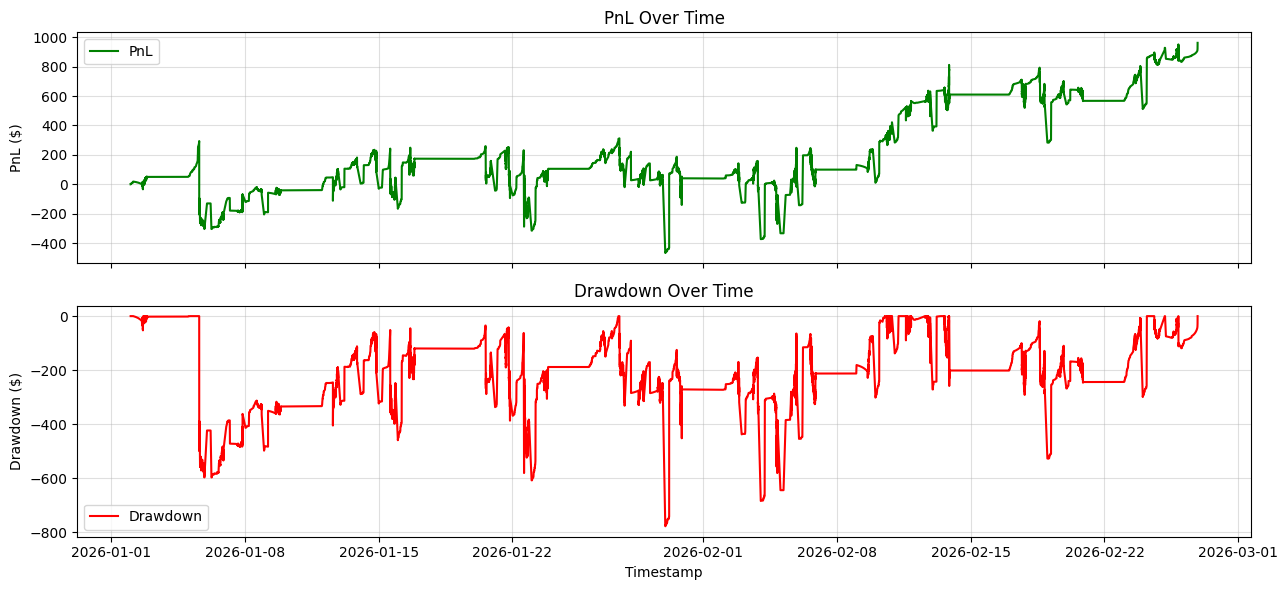

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate pnl from 'pnl' column
if "pnl" in sim_df.columns:
    pnl = sim_df["pnl"].to_numpy()
else:
    pnl = np.zeros(sim_df.height)

# Calculate running peak for drawdown
running_max = np.maximum.accumulate(pnl)
drawdown = pnl - running_max

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax[0].plot(sim_df["ts"].to_numpy(), pnl, label="PnL", color="green")
ax[0].set_ylabel("PnL ($)")
ax[0].set_title("PnL Over Time")
ax[0].grid(alpha=0.4)
ax[0].legend()

ax[1].plot(sim_df["ts"].to_numpy(), drawdown, label="Drawdown", color="red")
ax[1].set_ylabel("Drawdown ($)")
ax[1].set_title("Drawdown Over Time")
ax[1].grid(alpha=0.4)
ax[1].legend()

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# Use the 'returns' column for period returns if it exists, else fallback to zeros.
if "returns" in sim_df.columns:
    period_returns = sim_df["returns"].to_numpy()
else:
    period_returns = np.zeros(sim_df.height)

mean_return = np.mean(period_returns) * 252 * 6.5 * 60 * 60 if len(period_returns) > 0 else np.nan
volatility_return = np.std(period_returns) * np.sqrt(252 * 6.5 * 60 * 60) if len(period_returns) > 0 else np.nan
sharpe = mean_return / volatility_return if volatility_return not in [0, np.nan] else np.nan

# Compute 95% Value at Risk (VaR) and Conditional VaR (CVaR) for period returns
if len(period_returns) > 0:
    var_95 = np.percentile(period_returns, 5)
    cvar_95 = period_returns[period_returns <= var_95].mean() if np.any(period_returns <= var_95) else np.nan
else:
    var_95 = np.nan
    cvar_95 = np.nan

print(f"95% VaR: {var_95:.2f}")
print(f"95% CVaR: {cvar_95:.2f}")

print(f"Mean Return: {mean_return:.2f}")
print(f"Return Volatility: {volatility_return:.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")




95% VaR: -4.52
95% CVaR: -12.72
Mean Return: 284983.47
Return Volatility: 22433.80
Sharpe Ratio: 12.70


In [6]:
if "returns" in sim_df.columns:
    returns = sim_df["returns"].to_numpy()
    pct_negative_returns = 100 * np.sum(returns < 0) / len(returns)
    print(f"Percentage of ticks with negative return: {pct_negative_returns:.2f}%")
else:
    print("No 'returns' column found in sim_df.")

Percentage of ticks with negative return: 46.56%


/var/folders/z7/6ylvdmzs3qlbw9064h385ssr0000gn/T/ipykernel_43282/2357698840.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True, patch_artist=True)


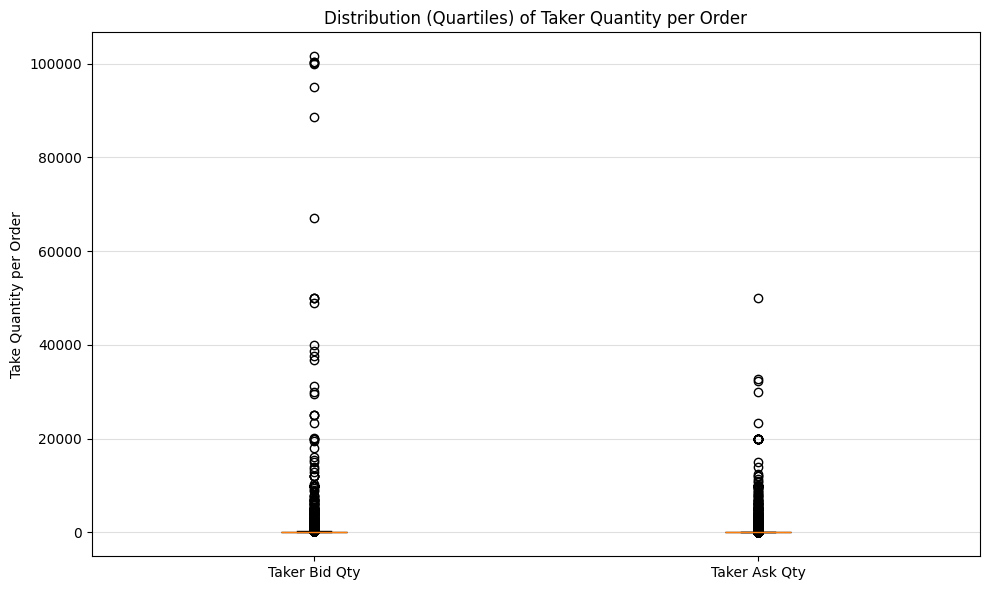

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Box plot (quartiles) for the take qty per order

has_bid_qty = "take_bid_qty" in sim_df.columns
has_ask_qty = "take_ask_qty" in sim_df.columns

import pandas as pd

if has_bid_qty or has_ask_qty:
    plt.figure(figsize=(10, 6))
    data = []
    labels = []

    if has_bid_qty:
        bid_qty = sim_df["take_bid_qty"].to_numpy()
        # Remove missing/nan and nonpositive values
        bid_qty = bid_qty[~np.isnan(bid_qty)]
        bid_qty = bid_qty[bid_qty > 0]
        if len(bid_qty) > 0:
            data.append(bid_qty)
            labels.append("Taker Bid Qty")

    if has_ask_qty:
        ask_qty = sim_df["take_ask_qty"].to_numpy()
        # Remove missing/nan and nonpositive values
        ask_qty = ask_qty[~np.isnan(ask_qty)]
        ask_qty = ask_qty[ask_qty > 0]
        if len(ask_qty) > 0:
            data.append(ask_qty)
            labels.append("Taker Ask Qty")

    if data:
        plt.boxplot(data, labels=labels, showfliers=True, patch_artist=True)
        plt.ylabel("Take Quantity per Order")
        plt.title("Distribution (Quartiles) of Taker Quantity per Order")
        plt.grid(alpha=0.4, axis="y")
        plt.tight_layout()
        plt.show()
    else:
        print("No taker qty data found for valid orders.")
else:
    print("No 'take_bid_qty' or 'take_ask_qty' column found in sim_df.")


In [8]:
# List the 20 highest taker qtys in sim_df

qty_cols = []
if "take_bid_qty" in sim_df.columns:
    qty_cols.append("take_bid_qty")
if "take_ask_qty" in sim_df.columns:
    qty_cols.append("take_ask_qty")

if qty_cols:
    # Stack all non-null, positive values from the respective columns
    all_qtys = []
    for col in qty_cols:
        arr = sim_df[col].to_numpy()
        arr = arr[~np.isnan(arr)]
        arr = arr[arr > 0]
        all_qtys.append(arr)
    if all_qtys:
        all_qtys_concat = np.concatenate(all_qtys)
        top_qtys = np.sort(all_qtys_concat)[::-1][:1000]
        print("Top 20 taker qtys (largest to smallest):")
        print(top_qtys)
    else:
        print("No positive taker qty data found.")
else:
    print("No 'take_bid_qty' or 'take_ask_qty' columns in sim_df.")


Top 20 taker qtys (largest to smallest):
[101580 100410 100285 100149  99900  94992  88578  67157  50000  50000
  50000  50000  48870  40000  38635  37657  36829  32706  32300  31178
  30000  30000  29611  25000  25000  25000  23442  23357  20118  20030
  20000  20000  20000  20000  20000  20000  20000  20000  20000  20000
  20000  20000  20000  19998  19992  19941  19890  19835  19578  17969
  16000  15492  15000  15000  14000  14000  13461  13000  12389  12116
  12039  12000  12000  12000  12000  11995  11318  11000  10764  10239
  10020  10006  10000  10000  10000  10000  10000  10000  10000  10000
  10000  10000  10000  10000  10000  10000  10000  10000  10000  10000
  10000  10000  10000  10000  10000  10000  10000  10000  10000   9995
   9992   9985   9900   9874   9860   9600   9541   9500   9491   9379
   9000   9000   8779   8772   8703   8500   8163   8067   8048   7894
   7815   7801   7715   7500   7500   7500   7206   7129   7100   7000
   7000   7000   7000   7000   7000 

No hedge

In [9]:
import polars as pl

# Load the 'simulation_no_hedge.parquet' file
sim_no_hedge_df = pl.read_parquet("simulation_no_hedge.parquet")

# Quick preview of the loaded DataFrame
sim_no_hedge_df.tail()

ts,contract_id,spx,vix,spy,take_bid,take_ask,take_bid_qty,take_ask_qty,fair_value,my_bid,my_ask,my_bid_size,my_ask_size,bid_fill,ask_fill,portfolio_value,pnl,returns,kalshi_delta_spx,pos_kalshi,pos_spy,cash,pending_trades,total_kalshi_inventory
"datetime[μs, America/New_York]",str,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,i64,i64,bool,bool,f64,f64,f64,f64,i64,i64,f64,i64,i64
2026-02-26 15:58:57 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,50,1.0,0.7,0.87,6,8,false,true,11471.046627,1471.046627,-3.31704,0.0,433,0,9800.61,0,1465
2026-02-26 15:58:59 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,null,0.99,0,101,1.0,0.7,0.87,7,9,false,true,11468.734241,1468.734241,-2.312387,0.0,425,0,9807.55,0,1457
2026-02-26 15:59:19 EST,"""KXINXU-26FEB26H1600-T6874.9999""",6948.27,17.96,693.27,0.99,null,71,0,1.0,0.77,0.92,18,20,false,false,11452.328289,1452.328289,-16.405951,0.0,310,0,9815.36,0,1448
2026-02-26 15:59:29 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.99,null,1,0,1.0,0.71,0.88,7,9,false,false,11442.376156,1442.376156,-9.952133,0.0,416,0,9815.36,0,1448
2026-02-26 15:59:43 EST,"""KXINXU-26FEB26H1600-T6899.9999""",6948.27,17.96,693.27,0.98,null,241,0,1.0,0.71,0.88,7,9,false,false,11425.836629,1425.836629,-16.539527,0.0,416,0,9815.36,0,1448


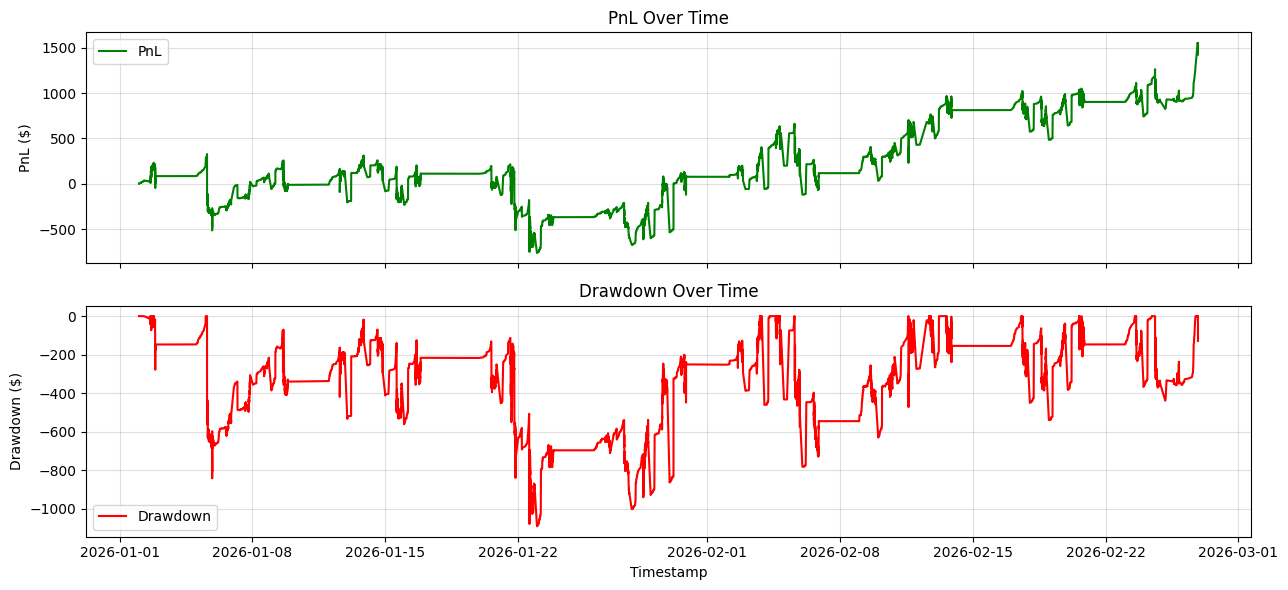

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate pnl from 'pnl' column
if "pnl" in sim_no_hedge_df.columns:
    pnl = sim_no_hedge_df["pnl"].to_numpy()
else:
    pnl = np.zeros(sim_no_hedge_df.height)

# Calculate running peak for drawdown
running_max = np.maximum.accumulate(pnl)
drawdown = pnl - running_max

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax[0].plot(sim_df["ts"].to_numpy(), pnl, label="PnL", color="green")
ax[0].set_ylabel("PnL ($)")
ax[0].set_title("PnL Over Time")
ax[0].grid(alpha=0.4)
ax[0].legend()

ax[1].plot(sim_df["ts"].to_numpy(), drawdown, label="Drawdown", color="red")
ax[1].set_ylabel("Drawdown ($)")
ax[1].set_title("Drawdown Over Time")
ax[1].grid(alpha=0.4)
ax[1].legend()

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

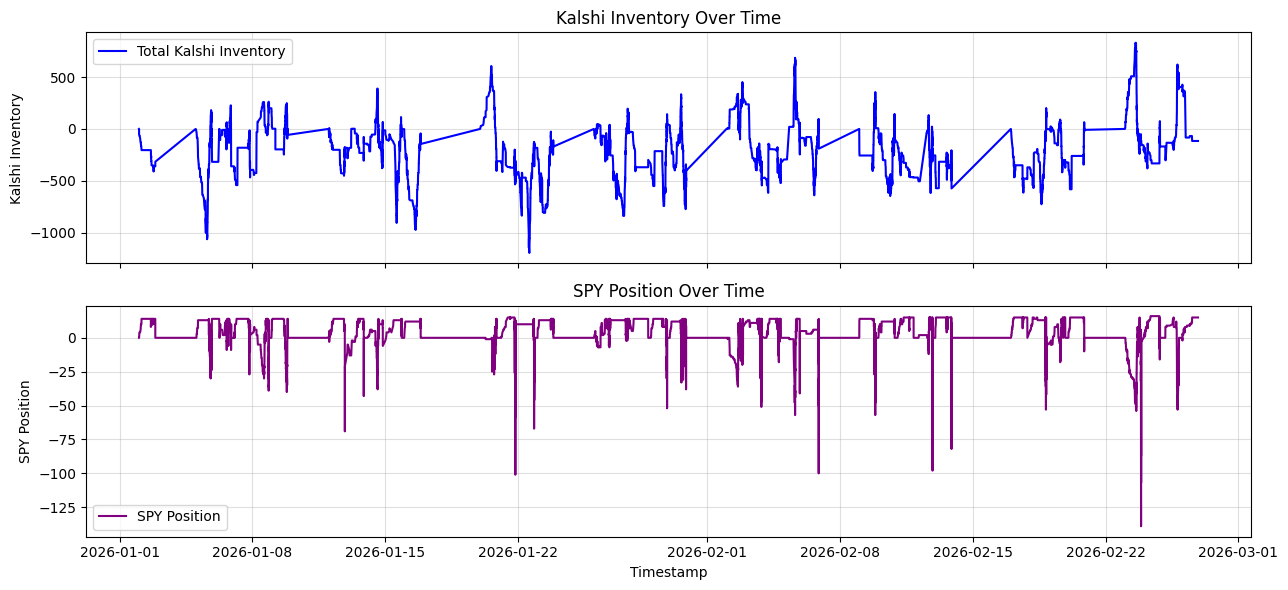

In [11]:
import matplotlib.pyplot as plt

# Plot Kalshi positions and SPY position over time using sim_df
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# 1. Plot total Kalshi inventory over time
if "total_kalshi_inventory" in sim_df.columns:
    ax[0].plot(sim_df["ts"].to_numpy(), sim_df["total_kalshi_inventory"].to_numpy(), label="Total Kalshi Inventory", color="blue")
    ax[0].set_ylabel("Kalshi Inventory")
    ax[0].set_title("Kalshi Inventory Over Time")
    ax[0].grid(alpha=0.4)
    ax[0].legend()
else:
    ax[0].set_visible(False)

# 2. Plot SPY position over time
if "pos_spy" in sim_df.columns:
    ax[1].plot(sim_df["ts"].to_numpy(), sim_df["pos_spy"].to_numpy(), label="SPY Position", color="purple")
    ax[1].set_ylabel("SPY Position")
    ax[1].set_title("SPY Position Over Time")
    ax[1].grid(alpha=0.4)
    ax[1].legend()
else:
    ax[1].set_visible(False)

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

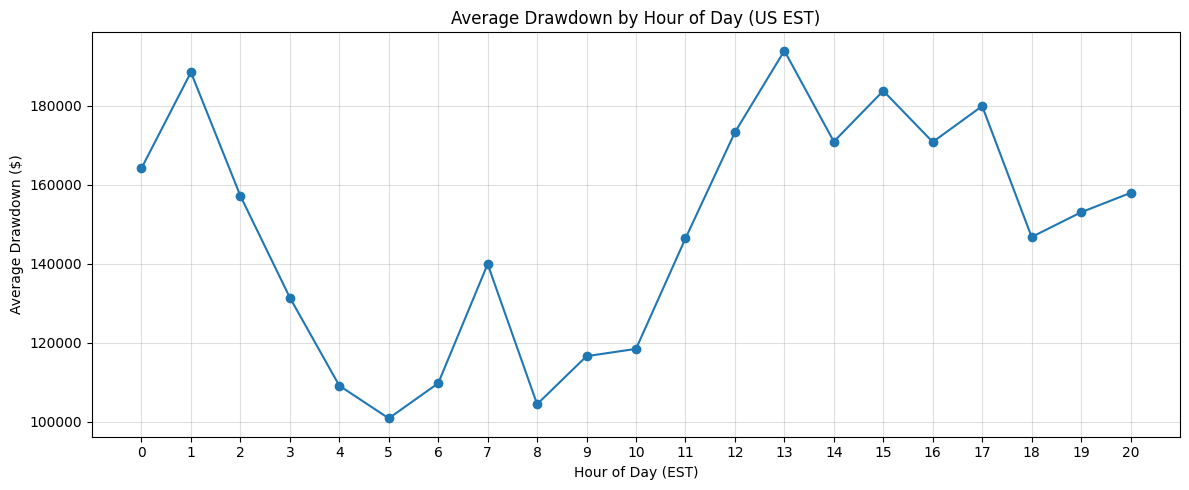

In [12]:
# Analyze the average drawdown by time of day (US EST, ~1 hr intervals) & plot them

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Compute equity curve (PnL) over time
if "equity_curve" in sim_df.columns:
    equity_curve = sim_df["equity_curve"].to_numpy()
elif "pnl" in sim_df.columns:
    equity_curve = np.cumsum(sim_df["pnl"].to_numpy())
else:
    raise ValueError("Could not find equity curve or pnl column in sim_df to analyze drawdowns.")

# Compute running maximum of the equity curve
running_max = np.maximum.accumulate(equity_curve)
drawdowns = running_max - equity_curve  # drawdown amounts (positive = drawdown)

# Prepare polars DataFrame for all drawdown events
pl_df = pl.DataFrame({
    "timestamp": sim_df["ts"].to_numpy(),
    "drawdown": drawdowns,
})

# Extract hour from timestamp (assume polars datetimes are timezone-aware in US EST)
pl_df = pl_df.with_columns(
    pl.col("timestamp").dt.hour().alias("hour")
)

# Group by hour and compute average drawdown
avg_drawdowns_by_hour = pl_df.group_by("hour").agg(
    pl.col("drawdown").mean().alias("avg_drawdown")
).sort("hour")

# Convert to numpy for plotting
hours = avg_drawdowns_by_hour["hour"].to_numpy()
avg_drawdown = avg_drawdowns_by_hour["avg_drawdown"].to_numpy()

# Plot average drawdown by hour of day
plt.figure(figsize=(12, 5))
plt.plot(hours, avg_drawdown, marker='o')
plt.title("Average Drawdown by Hour of Day (US EST)")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Drawdown ($)")
plt.grid(True, alpha=0.4)
plt.xticks(hours)
plt.tight_layout()
plt.show()

In [13]:
# To count Kalshi trades outside of market hours, we assume sim_df has trade records marked by a column that indicates a trade (e.g., 'pending_trades' or similar, otherwise all rows are trades).
# Market hours are typically 9:30 AM to 4:00 PM EST (inclusive). We'll use the 'ts' column.

# If there is a specific trade indicator column, filter on it, otherwise assume all rows are trade events.
TRADE_INDICATOR_COL = None
for col in sim_df.columns:
    if col.lower() in ['pending_trades', 'pending_trade', 'trade', 'is_trade', 'traded', 'num_trades']:
        TRADE_INDICATOR_COL = col
        break

# Prepare polars DataFrame (if not already done):
trades_df = pl.DataFrame(sim_df) if not isinstance(sim_df, pl.DataFrame) else sim_df

# Filter to only actual trades if there's a suitable column.
if TRADE_INDICATOR_COL:
    trades_df = trades_df.filter(pl.col(TRADE_INDICATOR_COL).cast(pl.Int64) > 0)

# Extract hour and minute from the timestamps
trades_df = trades_df.with_columns([
    pl.col("ts").dt.hour().alias("hour"),
    pl.col("ts").dt.minute().alias("minute")
])

# Market open is 9:30, market close is 16:00 (4:00 PM). Outside is hour < 9 OR (hour == 9 and minute < 30) OR hour > 16.
kalshi_trades_outside_market_hours = trades_df.filter(
    (pl.col("hour") < 9) |
    ((pl.col("hour") == 9) & (pl.col("minute") < 30)) |
    (pl.col("hour") >= 16)
)

num_outside = kalshi_trades_outside_market_hours.height

print(f"Number of Kalshi trades outside of market hours: {num_outside}")

Number of Kalshi trades outside of market hours: 531


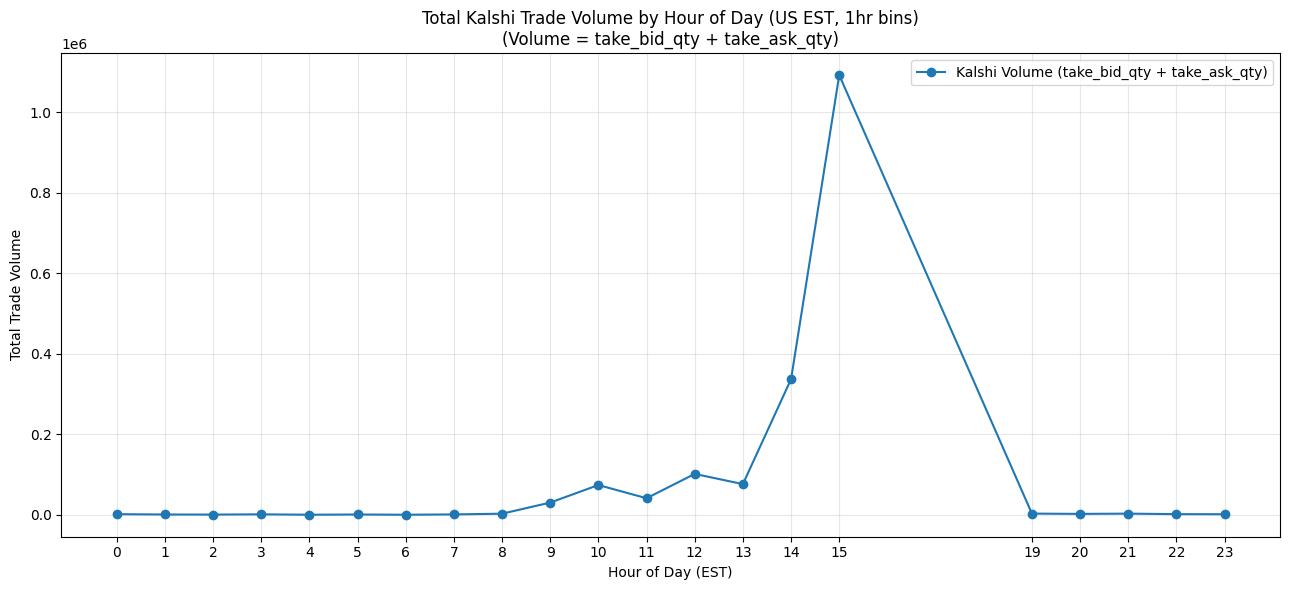

In [14]:
# Plot the average Kalshi trade volume by time of day (US EST, ~1hr chunks), aggregating all Kalshi trades
# Here, "Volume" is defined as take_bid_qty + take_ask_qty per hour.

import matplotlib.pyplot as plt

# We'll use the columns:
#   - "ts" (timestamp of trade, assumed to be already in America/New_York tz)
#   - "take_bid_qty" and "take_ask_qty"

TAKE_BID_COL = None
TAKE_ASK_COL = None
for col in trades_df.columns:
    if col.lower() in ['take_bid_qty', 'take_bid_vol', 'take_bid_volume', 'take_bid_size']:
        TAKE_BID_COL = col
    if col.lower() in ['take_ask_qty', 'take_ask_vol', 'take_ask_volume', 'take_ask_size']:
        TAKE_ASK_COL = col

if TAKE_BID_COL is None or TAKE_ASK_COL is None:
    raise ValueError("Could not find both take_bid_qty and take_ask_qty columns in trades_df.")

trades_df = trades_df.with_columns([
    (pl.col(TAKE_BID_COL) + pl.col(TAKE_ASK_COL)).alias("trade_volume"),
    pl.col("ts").dt.hour().alias("hour_of_day"),
])

# Compute average trade volume by hour of day (summed per hour first, then mean across all hours if needed)
grouped = (
    trades_df.group_by("hour_of_day")
    .agg(pl.col("trade_volume").sum().alias("total_trade_volume"))
    .sort("hour_of_day")
)

import pandas as pd
pdf = grouped.to_pandas()

plt.figure(figsize=(13, 6))
plt.plot(pdf["hour_of_day"], pdf["total_trade_volume"], "-o", label="Kalshi Volume (take_bid_qty + take_ask_qty)")
plt.title("Total Kalshi Trade Volume by Hour of Day (US EST, 1hr bins)\n(Volume = take_bid_qty + take_ask_qty)")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Total Trade Volume")
plt.xticks(sorted(pdf["hour_of_day"].unique()))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

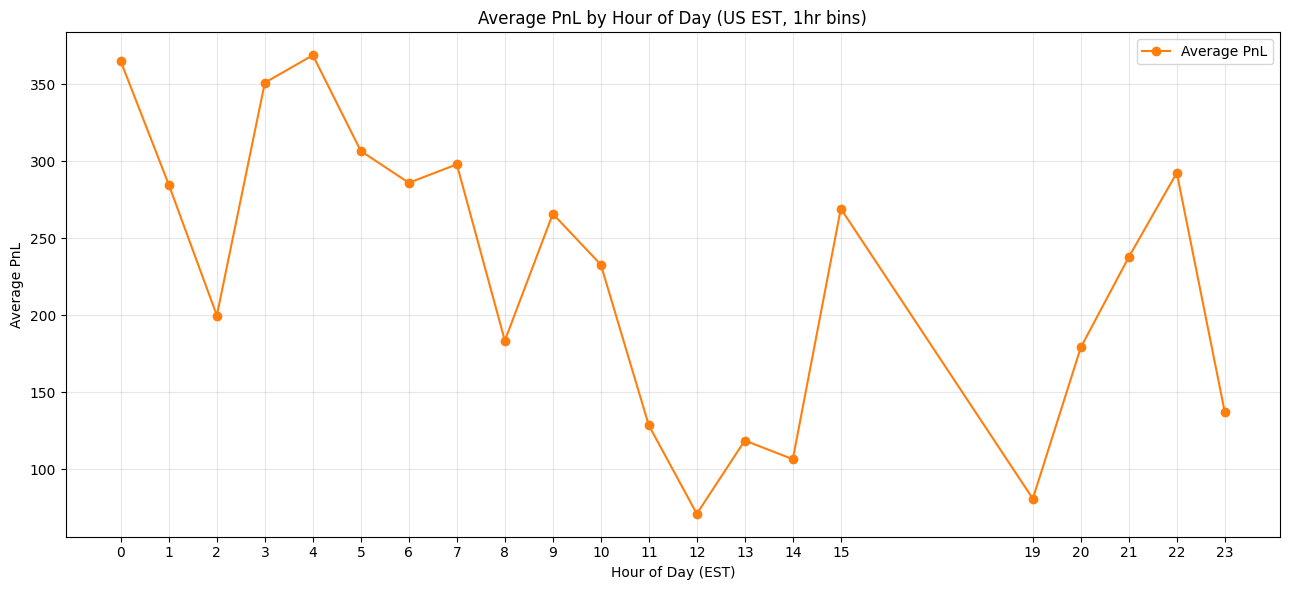

In [15]:
# Compute average pnl by hour

# We'll assume there's a column named "pnl" in your merged dataframe along with "ts"
if "pnl" not in trades_df.columns:
    raise ValueError("No 'pnl' column found in trades_df—you may need to join or compute it first.")

# Extract hour from timestamp and aggregate mean pnl by hour
pnl_by_hour = (
    trades_df
    .with_columns(pl.col("ts").dt.hour().alias("hour_of_day"))
    .group_by("hour_of_day")
    .agg(pl.col("pnl").mean().alias("avg_pnl"))
    .sort("hour_of_day")
)

# Convert to pandas for plotting
pnl_pdf = pnl_by_hour.to_pandas()

plt.figure(figsize=(13, 6))
plt.plot(pnl_pdf["hour_of_day"], pnl_pdf["avg_pnl"], marker="o", color="C1", label="Average PnL")
plt.title("Average PnL by Hour of Day (US EST, 1hr bins)")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average PnL")
plt.xticks(sorted(pnl_pdf["hour_of_day"].unique()))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

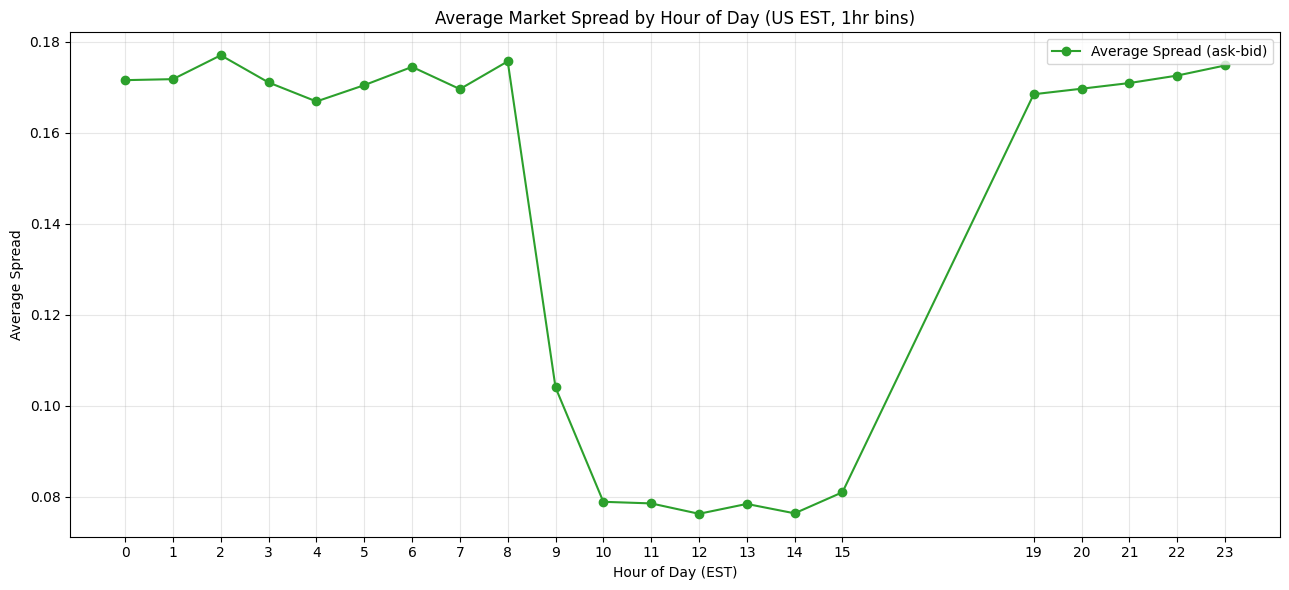

In [16]:
# Plot the average spread (ask - bid) by hour of day

# We'll assume you have a dataframe `quotes_df` with columns "ts", "bid", "ask"
if not all(col in sim_df.columns for col in ["ts", "my_bid", "my_ask"]):
    raise ValueError("Expected columns 'ts', 'my_bid', 'my_ask' in sim_df.")

import polars as pl

# Compute spread and hour of day
spread_by_hour = (
    sim_df
    .with_columns([
        (pl.col("my_ask") - pl.col("my_bid")).alias("spread"),
        pl.col("ts").dt.hour().alias("hour_of_day"),
    ])
    .group_by("hour_of_day")
    .agg(pl.col("spread").mean().alias("avg_spread"))
    .sort("hour_of_day")
)

# Convert to pandas for plotting
spread_pdf = spread_by_hour.to_pandas()

plt.figure(figsize=(13, 6))
plt.plot(spread_pdf["hour_of_day"], spread_pdf["avg_spread"], marker="o", color="C2", label="Average Spread (ask-bid)")
plt.title("Average Market Spread by Hour of Day (US EST, 1hr bins)")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Spread")
plt.xticks(sorted(spread_pdf["hour_of_day"].unique()))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

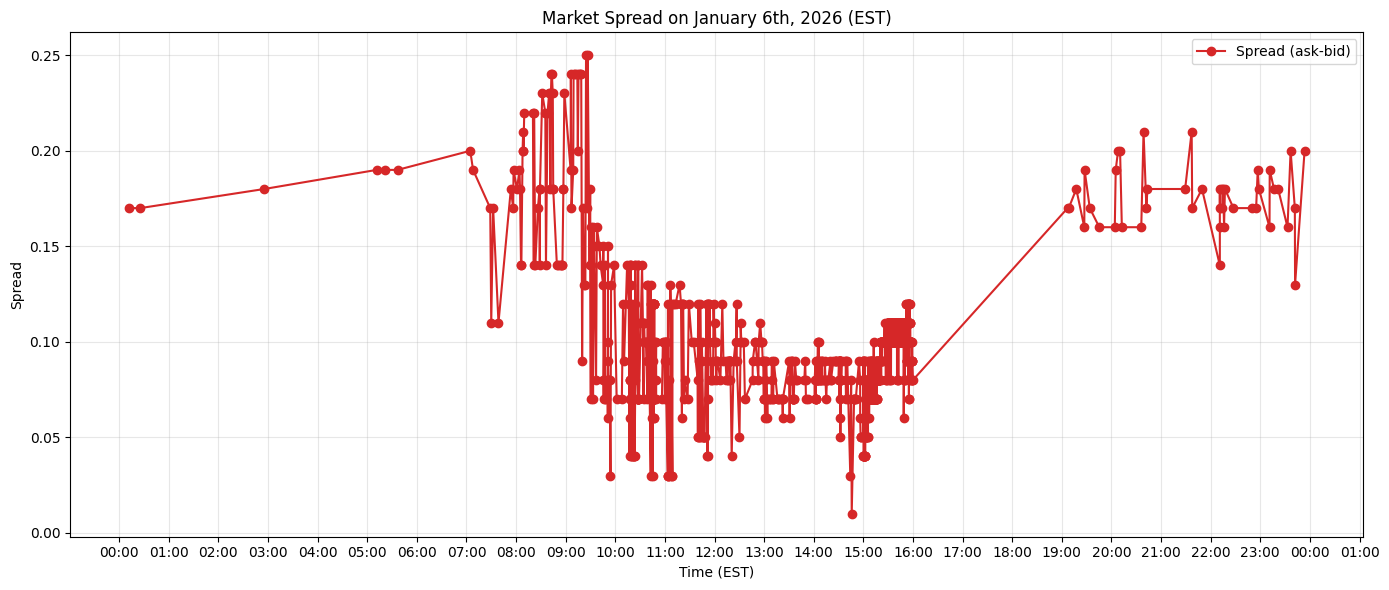

In [17]:
# Plot the spread (my_ask - my_bid) specifically for Jan 6th with X axis in EST

import matplotlib.dates as mdates
import pytz

# Filter sim_df for January 6th (assuming date is in the timestamp)
jan6_df = sim_df.filter(
    pl.col("ts").dt.date().cast(str) == "2026-01-15"
)

# Check there are results
if jan6_df.height == 0:
    print("No data available for Jan 6th.")
else:
    jan6_pdf = jan6_df.select([
        pl.col("ts"),
        (pl.col("my_ask") - pl.col("my_bid")).alias("spread"),
    ]).to_pandas()

    # Convert ts to EST timezone if it's not already
    if jan6_pdf["ts"].dt.tz is None or str(jan6_pdf["ts"].dt.tz) != "America/New_York":
        # Try to convert to EST if ts is naive or in a different tz
        jan6_pdf["ts"] = jan6_pdf["ts"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")

    plt.figure(figsize=(14, 6))
    plt.plot(jan6_pdf["ts"], jan6_pdf["spread"], marker="o", linestyle="-", color="C3", label="Spread (ask-bid)")
    plt.title("Market Spread on January 6th, 2026 (EST)")
    plt.xlabel("Time (EST)")
    plt.ylabel("Spread")
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone("America/New_York")))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
# Most unique Kalshi contracts held at once (max number of distinct contracts with nonzero inventory at any timestamp)

# Per (ts, contract_id) we have pos_kalshi; count distinct contract_ids with nonzero inventory per ts
contracts_per_ts = (
    sim_df.filter(pl.col("pos_kalshi").fill_null(0) != 0)
    .group_by("ts")
    .agg(pl.col("contract_id").n_unique().alias("num_unique_contracts"))
)

max_unique_contracts = contracts_per_ts["num_unique_contracts"].max()
print("Most unique Kalshi contracts held at once:", max_unique_contracts)

# Timestamp(s) when this occurred
max_times = contracts_per_ts.filter(pl.col("num_unique_contracts") == max_unique_contracts)
print("Timestamp(s) with max unique contracts held:\n", max_times)

Most unique Kalshi contracts held at once: 5
Timestamp(s) with max unique contracts held:
 shape: (2, 2)
┌────────────────────────────────┬──────────────────────┐
│ ts                             ┆ num_unique_contracts │
│ ---                            ┆ ---                  │
│ datetime[μs, America/New_York] ┆ u32                  │
╞════════════════════════════════╪══════════════════════╡
│ 2026-01-05 07:59:04 EST        ┆ 5                    │
│ 2026-02-06 11:52:41 EST        ┆ 5                    │
└────────────────────────────────┴──────────────────────┘


In [19]:
# Find the lowest cash balance encountered in the simulation dataframe.
min_cash = sim_df["cash"].min()
print("Lowest cash balance encountered:", min_cash)

Lowest cash balance encountered: 46.74000000005867


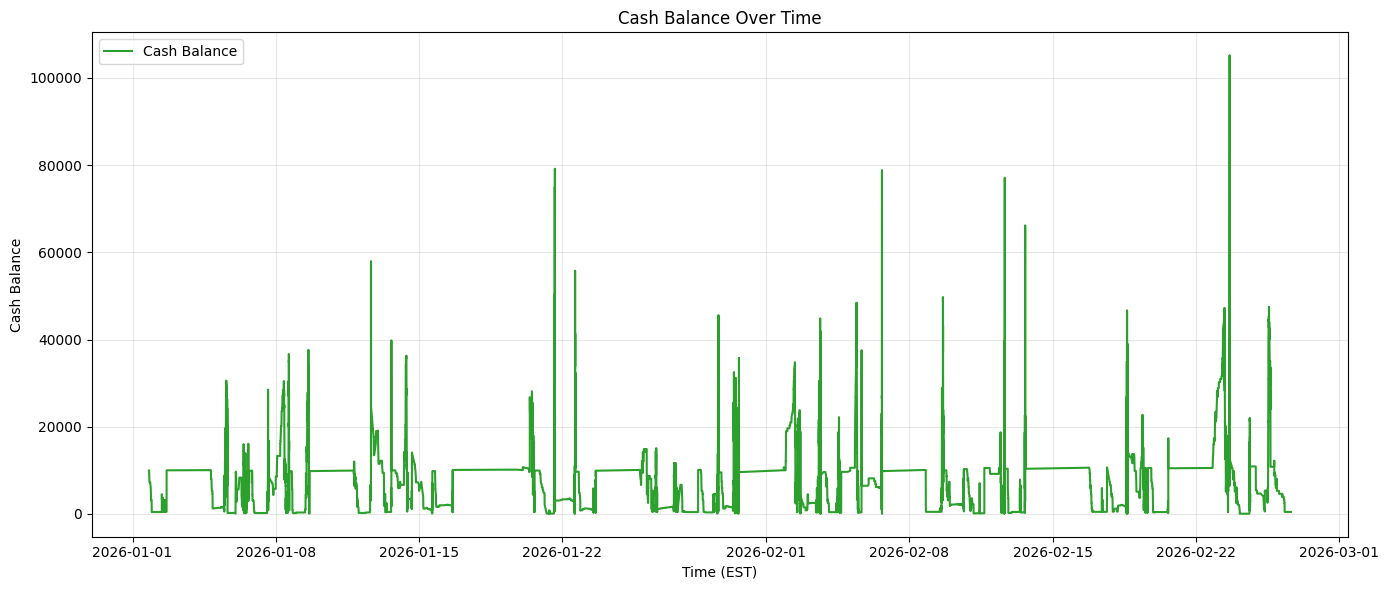

In [20]:
# Plot cash balance over time
plt.figure(figsize=(14, 6))
plt.plot(sim_df["ts"].to_pandas(), sim_df["cash"].to_pandas(), color="C2", label="Cash Balance")
plt.xlabel("Time (EST)")
plt.ylabel("Cash Balance")
plt.title("Cash Balance Over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Calculate and print the final positions in Kalshi and SPY at the end of the simulation.
final_row = sim_df[-1]

final_pos_kalshi = final_row["pos_kalshi"]
final_pos_spy = final_row["pos_spy"]
final_cash = final_row["cash"]

print("Final Kalshi contract position:", final_pos_kalshi)
print("Final SPY position:", final_pos_spy)
print("Final cash:", final_cash)

Final Kalshi contract position: shape: (1,)
Series: 'pos_kalshi' [i64]
[
	84
]
Final SPY position: shape: (1,)
Series: 'pos_spy' [i64]
[
	15
]
Final cash: shape: (1,)
Series: 'cash' [f64]
[
	475.28
]


shape: (47, 2)
┌────────────┬──────────────┐
│ date       ┆ daily_return │
│ ---        ┆ ---          │
│ date       ┆ f64          │
╞════════════╪══════════════╡
│ 2026-01-01 ┆ null         │
│ 2026-01-02 ┆ 21.112313    │
│ 2026-01-04 ┆ -0.870955    │
│ 2026-01-05 ┆ -0.811592    │
│ 2026-01-06 ┆ 0.277176     │
│ …          ┆ …            │
│ 2026-02-22 ┆ 1.040344     │
│ 2026-02-23 ┆ -0.885979    │
│ 2026-02-24 ┆ 1.233068     │
│ 2026-02-25 ┆ -0.023698    │
│ 2026-02-26 ┆ -0.910644    │
└────────────┴──────────────┘


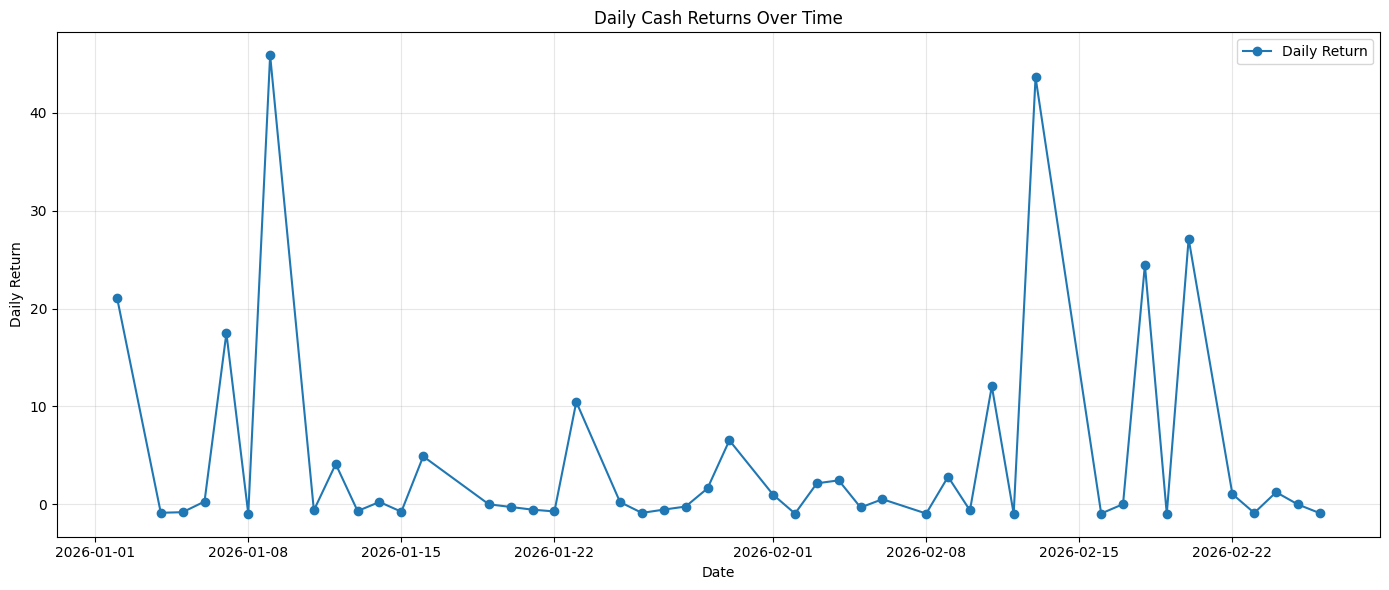

In [22]:
# Calculate daily returns 

# Convert timestamps to date for grouping
sim_df = sim_df.with_columns(
    pl.col("ts").dt.date().alias("date")
)

# Compute daily close cash by taking the cash at the last timestamp of each day
daily_cash_df = (
    sim_df
    .sort(["date", "ts"])
    .group_by("date")
    .agg([
        pl.col("cash").last().alias("daily_close_cash")
    ])
    .sort("date")
)

# Calculate daily returns: (close_today - close_yesterday) / close_yesterday
daily_cash_df = daily_cash_df.with_columns(
    (pl.col("daily_close_cash") / pl.col("daily_close_cash").shift(1) - 1).alias("daily_return")
)

# Print daily returns
print(daily_cash_df.select(["date", "daily_return"]))

# (Optional) Plot daily returns over time
plt.figure(figsize=(14, 6))
plt.plot(daily_cash_df["date"].to_pandas(), daily_cash_df["daily_return"].to_pandas(), marker="o", label="Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Daily Cash Returns Over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

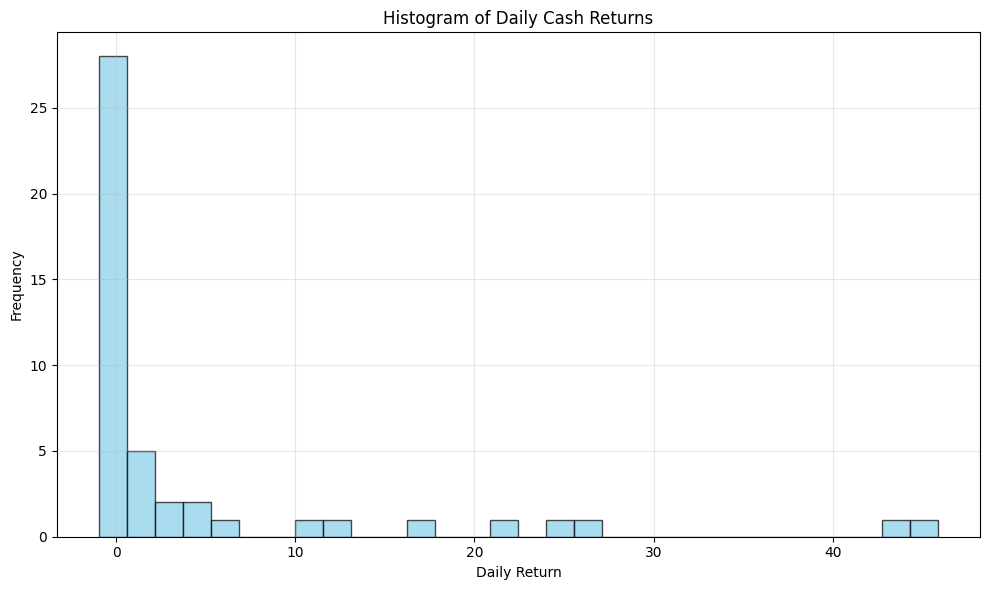

In [23]:
# Create a histogram of daily returns

plt.figure(figsize=(10, 6))
plt.hist(daily_cash_df["daily_return"].drop_nulls().to_numpy(), bins=30, color="skyblue", edgecolor="k", alpha=0.7)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Histogram of Daily Cash Returns")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import scipy.stats as stats

# Compute statistics for daily returns (dropping nulls for accurate stats)
returns = daily_cash_df["daily_return"].drop_nulls().to_numpy()

# Mean
mean_return = np.mean(returns) * 252
# Volatility (standard deviation)
volatility = np.std(returns, ddof=1) * np.sqrt(252)
# Sharpe ratio (assuming risk-free rate = 0)
sharpe_ratio = mean_return / volatility if volatility != 0 else np.nan
# 5% Value at Risk (VaR)
var_95 = np.percentile(returns, 5)
# 5% Conditional VaR (CVaR, aka Expected Shortfall)
cvar_95 = returns[returns <= var_95].mean() if np.any(returns <= var_95) else np.nan

print(f"Mean daily return:       {mean_return:.6f}")
print(f"Volatility:              {volatility:.6f}")
print(f"Sharpe ratio:            {sharpe_ratio:.2f}")
print(f"5% Value at Risk (VaR):  {var_95:.6f}")
print(f"5% Conditional VaR:      {cvar_95:.6f}")

Mean daily return:       1182.125960
Volatility:              174.859837
Sharpe ratio:            6.76
5% Value at Risk (VaR):  -0.960844
5% Conditional VaR:      -0.970364
